# Workshop 2 — Machine Learning · Clasificación: Thyroid Disease Data

**Unidad 2 — Pipelines, entrenamiento, comparación de modelos y validación cruzada**

**Curso:** Fundamentos de Aprendizaje Automático — Ingeniería de Sistemas — EAFIT — 2026-2
**Profesor:** Yomin Estiven Jaramillo Múnera

**Responsable de esta parte:** `Jose Alejandro Jimenez` — **Fase 1 completa (puntos 1 a 10)**

**Dataset:** Thyroid Disease Data — [Kaggle](https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data)
**Archivo fuente:** `data/tiroides/Thyroid_Diff.csv`
**Variable objetivo:** `Recurred` (Yes / No) — **clasificación binaria supervisada**

---

## Alcance de este notebook

Este notebook desarrolla la **Fase 1 — EDA, limpieza y preprocesamiento** del workshop, punto por punto:

| Punto | Tema |
|---|---|
| 1 | Documentación del dataset, problema de salud y variable objetivo |
| 2 | Carga, `head()`/`tail()`, `.shape`, `.info()` y diccionario de datos |
| 3 | `.describe()` e interpretación de estadísticos |
| 4 | Valores nulos por columna y estrategia de imputación |
| 5 | Identificación y eliminación de duplicados |
| 6 | Inconsistencias de formato en columnas categóricas |
| 7 | Detección de outliers con el criterio IQR |
| 8 | Gráficas de EDA con interpretación y recomendación |
| 9 | Técnica de codificación por variable categórica |
| 10 | Necesidad y técnica de escalamiento de las numéricas |

Cada punto va acompañado de la celda de justificación que exige el enunciado: no basta con ejecutar el código, hay que sustentar por qué se tomó cada decisión.

Las fases 2 a 8 (partición train/validation/test, pipelines con `ColumnTransformer`, entrenamiento y comparación de los cuatro modelos de clasificación, métricas, matriz de confusión, evaluación en test, validación cruzada y conclusiones) quedan a cargo del resto del equipo y se apoyan directamente en la especificación de preprocesamiento que se define aquí en los puntos 9 y 10.

## Cómo reproducir este notebook

```
python -m venv .venv
source .venv/bin/activate        # Linux / macOS
.\.venv\Scripts\Activate.ps1     # Windows
pip install -r requirements.txt
jupyter lab
```

El notebook se ejecuta de arriba hacia abajo. La ruta del CSV es relativa a esta carpeta (`talleres/workshop2-ml/`), así que hay que abrirlo desde aquí. Los CSV no están versionados en el repositorio; el README de la carpeta indica cómo descargarlos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110

RUTA = "data/tiroides/Thyroid_Diff.csv"

print("Versiones del entorno")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  seaborn     {sns.__version__}")


Versiones del entorno
  pandas      3.0.5
  numpy       2.5.1
  seaborn     0.13.2


## Punto 1 — El problema de salud y la variable objetivo

### 1.1 Contexto clínico

El conjunto de datos *Thyroid Disease Data* recoge el seguimiento de **383 pacientes diagnosticados con carcinoma diferenciado de tiroides**, observados durante **más de 10 años**. Para cada paciente se registran 15 variables clínico-patológicas disponibles en el momento del diagnóstico (datos demográficos, antecedentes, hallazgos del examen físico, histología y estadificación TNM), más la respuesta al tratamiento inicial evaluada en el seguimiento, y finalmente si la enfermedad reapareció o no. Son 15 + 1 + 1 = **17 columnas**, exactamente las que reporta el `df.info()` del Punto 2.

El carcinoma diferenciado de tiroides es el **cáncer endocrino más frecuente**. Su comportamiento es peculiar dentro de la oncología: el pronóstico general es muy favorable, con supervivencias a 10 años que en la mayoría de series superan el 90 %, pero eso no significa que el problema esté resuelto. Una fracción nada despreciable de los pacientes presenta **recurrencia** años después del tratamiento inicial (cirugía, con o sin yodo radioactivo). Esa combinación —mortalidad baja pero recurrencia apreciable— es exactamente lo que obliga a mantener a los pacientes en un seguimiento prolongado, con ecografías periódicas, medición de tiroglobulina y consultas de control que se extienden durante décadas. Ese seguimiento es costoso para el sistema de salud y desgastante para el paciente.

### 1.2 El problema que realmente se está resolviendo

Conviene precisar algo que puede confundirse a primera vista: **este no es un problema de diagnóstico**. Todos los pacientes de la cohorte ya tienen el cáncer confirmado histológicamente; no hay controles sanos con los cuales comparar. El problema es de **pronóstico**: dado un paciente ya tratado, ¿va a recurrir su enfermedad?

La decisión clínica que se apoya con esa predicción es concreta y tiene dos caras:

- **Intensidad y frecuencia del seguimiento.** A un paciente con riesgo alto de recurrencia se le justifica un control más estrecho y más frecuente; a uno con riesgo muy bajo se le puede espaciar el seguimiento sin exponerlo a un peligro real, liberando recursos.
- **Candidatura a terapias adyuvantes.** Un riesgo alto puede inclinar la decisión hacia yodo radioactivo o hacia una supresión más agresiva de TSH, tratamientos que no son inocuos y que no tiene sentido aplicar de forma indiscriminada.

### 1.3 Variable objetivo

La variable objetivo es **`Recurred`**, de tipo binario con valores `Yes` / `No`, que indica si el paciente presentó recurrencia de la enfermedad durante el periodo de seguimiento. Esto define el problema como una tarea de **clasificación binaria supervisada**, donde la clase positiva de interés es `Yes` (recurrencia).

### 1.4 Desbalance de clases y elección de métricas

La distribución del objetivo no es equilibrada: aproximadamente **71,8 % de casos `No`** frente a **28,2 % de casos `Yes`**. Es un desbalance moderado, no extremo, pero suficiente para condicionar la evaluación del modelo. La consecuencia práctica es directa: un clasificador trivial que siempre respondiera "no recurre" alcanzaría un **71,8 % de *accuracy*** sin haber aprendido absolutamente nada del problema (esa cifra corresponde a las 383 filas del archivo original; tras eliminar los duplicados en el Punto 5 la línea base baja a 70,33 % sobre las 364 filas con las que realmente se entrena, que es la referencia contra la que habrá que comparar el modelo). Reportar únicamente *accuracy* sería, entonces, engañoso.

Por eso, desde este punto se deja establecido que la evaluación se apoyará en el ***recall*** y el ***F1* sobre la clase positiva**, además de la matriz de confusión y del AUC-ROC, y no en la exactitud global. Este criterio se retoma y se justifica formalmente en la Fase 5.

### 1.5 Asimetría en el costo de los errores

Los dos tipos de error no cuestan lo mismo, y en un problema clínico eso no es un detalle:

- Un **falso negativo** (el modelo predice que el paciente no recurrirá y sí recurre) implica relajar el seguimiento de alguien que lo necesitaba. Se pierde la ventana de detección temprana, y la recurrencia se descubre más tarde, más grande y con peores opciones terapéuticas.
- Un **falso positivo** (el modelo predice recurrencia en alguien que no recurrirá) implica sobreseguimiento: más consultas, más ecografías, más costo y, sobre todo, ansiedad innecesaria para el paciente. Es un daño real, pero reversible y clínicamente menos grave que el anterior.

Dado que el costo del falso negativo es claramente superior, la métrica que se priorizará es el **recall de la clase `Yes`**, aceptando conscientemente una pérdida de precisión a cambio.

### 1.6 Nota metodológica sobre la variable `Response`

Hay un punto que conviene dejar explícito antes de modelar, porque de lo contrario se corre el riesgo de construir un modelo con un desempeño artificialmente bueno. La variable `Response` describe la **respuesta al tratamiento inicial**, y se mide **después** de la cirugía y del tratamiento con yodo radioactivo, no en el momento del diagnóstico. No es, por tanto, una variable basal.

Esto abre dos marcos temporales posibles, y la validez de `Response` como predictor depende de cuál se adopte:

1. **Predicción en el momento del diagnóstico** (antes de tratar). Bajo este marco, `Response` todavía no existe, y usarla constituiría una **fuga temporal de información** (*data leakage*): el modelo estaría espiando el futuro y su desempeño en validación no sería reproducible en la práctica.
2. **Apoyo a la decisión de seguimiento tras el tratamiento.** Bajo este marco, el paciente ya fue operado, ya se evaluó su respuesta inicial, y la pregunta es cuán intensamente vigilarlo de aquí en adelante. Aquí `Response` está legítimamente disponible y es, de hecho, una de las variables más informativas de que dispone el clínico.

**En este trabajo se adopta el segundo marco**: el modelo se entiende como una herramienta de apoyo a la planificación del seguimiento post-tratamiento, con `Response` disponible como predictor. La razón es que ese es el escenario que corresponde a los datos tal como fueron recogidos y a la decisión que el análisis pretende informar. La observación se retoma en el punto de codificación de variables, donde `Response` se tratará como categórica ordinal.

### 1.7 Pregunta que guía el análisis

> **A partir de las características clínicas, patológicas y de estadificación de un paciente con carcinoma diferenciado de tiroides, junto con su respuesta al tratamiento inicial, ¿es posible predecir si la enfermedad recurrirá, con un *recall* suficientemente alto sobre los casos de recurrencia como para orientar la intensidad del seguimiento?**


## Punto 2 — Carga del dataset y exploración estructural

Se carga el archivo con `pandas` y se inspecciona su estructura: dimensiones, primeras y últimas filas, tipos de dato y presencia de nulos. En este bloque **no se modifica nada**: el objetivo es documentar el dataset tal como viene de la fuente. Las correcciones (nombres de columna, duplicados) se abordan en el bloque de limpieza.


In [2]:
df = pd.read_csv(RUTA)

print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


Filas:    383
Columnas: 17


In [3]:
# Primeras y últimas filas para verificar que la carga fue correcta y que no
# se coló una columna índice espuria ni un pie de tabla al final del archivo.
display(df.head(5))
display(df.tail(5))


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

### 2.1 Diccionario de datos

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Age` | Numérica discreta (entero, años) | Edad del paciente en el momento del diagnóstico. Es la única variable cuantitativa del conjunto y además interviene en la definición del estadio TNM, por lo que tiene peso pronóstico propio. |
| `Gender` | Categórica nominal (`F`, `M`) | Sexo del paciente. La patología es marcadamente más frecuente en mujeres, lo que se refleja en el fuerte desbalance de esta columna. |
| `Smoking` | Categórica binaria (`Yes`, `No`) | Indica si el paciente es fumador **activo** al momento del registro. |
| `Hx Smoking` | Categórica binaria (`Yes`, `No`) | Antecedente de tabaquismo. El prefijo `Hx` es la abreviatura clínica de *history of* (historia de). Es distinta de `Smoking`: recoge el consumo pasado, no el actual. |
| `Hx Radiothreapy` | Categórica binaria (`Yes`, `No`) | Antecedente de radioterapia previa sobre cabeza o cuello, factor de riesgo clásico y bien documentado para el desarrollo de cáncer tiroideo. **El nombre de la columna viene mal escrito en el archivo original** (`Radiothreapy` en vez de `Radiotherapy`). |
| `Thyroid Function` | Categórica nominal (5 niveles) | Estado funcional de la glándula al diagnóstico: normofunción (`Euthyroid`) o alguna forma de hiper/hipofunción, clínica o subclínica. Describe cómo está trabajando la tiroides, con independencia del tumor. |
| `Physical Examination` | Categórica nominal (5 niveles) | Hallazgo obtenido al palpar el cuello: cuello normal, bocio difuso, bocio multinodular o nódulo único (con su lateralidad). Es la primera aproximación clínica al tamaño y distribución de la lesión. |
| `Adenopathy` | Categórica nominal (6 niveles) | Presencia y localización de ganglios linfáticos cervicales aumentados de tamaño (`No`, `Right`, `Left`, `Bilateral`, `Posterior`, `Extensive`). La afectación ganglionar es uno de los indicadores de diseminación regional. |
| `Pathology` | Categórica nominal (4 niveles) | Subtipo histológico del carcinoma determinado por el estudio anatomopatológico: papilar, micropapilar, folicular o de células de Hürthle. Cada subtipo tiene un comportamiento biológico y un pronóstico distintos. |
| `Focality` | Categórica binaria (`Uni-Focal`, `Multi-Focal`) | Indica si el tumor se presenta como un único foco dentro de la glándula o como varios focos simultáneos. La multifocalidad se asocia a mayor probabilidad de enfermedad residual. |
| `Risk` | Categórica **ordinal** (`Low` < `Intermediate` < `High`) | Categoría de riesgo de recurrencia según la estratificación de la *American Thyroid Association* (ATA). Es una síntesis que el clínico ya construye combinando histología, extensión y compromiso ganglionar. |
| `T` | Categórica **ordinal** (`T1a` < `T1b` < `T2` < `T3a` < `T3b` < `T4a` < `T4b`) | Componente **tumor** del sistema TNM: describe el tamaño del tumor primario y su grado de extensión hacia las estructuras vecinas del cuello. |
| `N` | Categórica **ordinal** (`N0` < `N1a` < `N1b`) | Componente **nodos** del TNM: compromiso de los ganglios linfáticos regionales. `N0` indica ausencia de compromiso; `N1a` y `N1b` distinguen los niveles ganglionares afectados. |
| `M` | Categórica **ordinal** (`M0` < `M1`) | Componente **metástasis** del TNM: presencia de metástasis a distancia, típicamente pulmonares u óseas. Es el marcador de enfermedad diseminada. |
| `Stage` | Categórica **ordinal** (`I` < `II` < `III` < `IVA` < `IVB`) | Estadio clínico agregado, derivado de la combinación de T, N, M y la edad del paciente. Resume en un solo valor la extensión de la enfermedad. |
| `Response` | Categórica **ordinal** (`Excellent` < `Indeterminate` < `Biochemical Incomplete` < `Structural Incomplete`) | Respuesta al tratamiento inicial (cirugía con o sin yodo radioactivo), evaluada durante el seguimiento. Como se discutió en el Punto 1, es una medición **posterior** al tratamiento. |
| `Recurred` | Categórica binaria (`Yes`, `No`) — **variable objetivo** | Indica si la enfermedad reapareció durante el periodo de seguimiento. Es lo que se quiere predecir. |

### 2.2 Observaciones sobre los nombres de las columnas

Dos observaciones sobre los encabezados, que se resuelven en el bloque de limpieza:

1. **Error tipográfico.** La columna `Hx Radiothreapy` está mal escrita en el archivo fuente; lo correcto sería `Hx Radiotherapy`. Se conserva tal cual en esta fase para no alterar los datos originales antes de documentarlos, y se corregirá al limpiar.
2. **Espacios en los nombres.** Las columnas `Hx Smoking`, `Hx Radiothreapy`, `Thyroid Function` y `Physical Examination` contienen espacios, lo que impide el acceso por atributo (`df.Hx Smoking` es sintácticamente inválido). Aun así, **los nombres se conservan tal como vienen en el archivo**: la única modificación que se hará sobre los encabezados es la corrección tipográfica del punto anterior. El motivo es que el `ColumnTransformer` de la Fase 2 referencia las columnas por nombre, como cadenas de texto, y un espacio no le supone ningún problema, mientras que renombrarlas rompería la trazabilidad con la fuente. La justificación completa se da en el Punto 6.

### 2.3 Clasificación de las variables

- **Numéricas:** `Age`. Y nada más.
- **Categóricas nominales** (sin orden intrínseco): `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Thyroid Function`, `Physical Examination`, `Adenopathy`, `Pathology`, `Focality`.
- **Categóricas ordinales** (con un orden clínico claro y significativo): `Risk`, `T`, `N`, `M`, `Stage`, `Response`.

Esta distinción no es un ejercicio taxonómico: es precisamente la que determinará **la técnica de codificación** que se aplique a cada grupo en el Punto 9. Las nominales exigen *one-hot encoding*, porque asignarles números consecutivos introduciría un orden que no existe. Las ordinales, en cambio, admiten codificación ordinal con un mapeo explícito, lo que preserva información real (que `T4b` es peor que `T1a`) y evita multiplicar innecesariamente la dimensionalidad.

Vale la pena subrayar el hecho estructural más importante de este dataset: **16 de sus 17 columnas son categóricas**. Esto condiciona todo el preprocesamiento posterior. No habrá casi nada que escalar o normalizar, el análisis exploratorio se apoyará en tablas de contingencia y gráficos de barras más que en histogramas o dispersogramas, las medidas de asociación adecuadas serán chi-cuadrado y Cramér's V en lugar de la correlación de Pearson, y la dimensionalidad final del conjunto codificado dependerá casi por completo de las decisiones que se tomen sobre estas variables.


## Punto 3 — Estadísticos descriptivos


In [5]:
# Solo devuelve una columna: Age es la única variable numérica del conjunto.
display(df.describe())


,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [6]:
# include="all" agrega el resumen de las categóricas: count, unique, top y freq.
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,383.0,NaN,NaN,NaN,40.866841,15.134494,15.0,29.0,37.0,51.0,82.0
Gender,383,2,F,312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking,383,2,No,334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hx Smoking,383,2,No,355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hx Radiothreapy,383,2,No,376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thyroid Function,383,5,Euthyroid,332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Physical Examination,383,5,Multinodular goiter,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adenopathy,383,6,No,277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pathology,383,4,Papillary,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Focality,383,2,Uni-Focal,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Asimetría de la distribución de edad.
print(f"Asimetría (skew) de Age: {df['Age'].skew():.3f}")
print()

# Edad desagregada por la variable objetivo.
display(df.groupby("Recurred")["Age"].describe())


Asimetría (skew) de Age: 0.720



,count,mean,std,min,25%,50%,75%,max
Recurred,,,,,,,,
No,275.0,38.414545,12.946654,17.0,28.00,36.0,46.0,81.0
Yes,108.0,47.111111,18.267654,15.0,31.75,44.5,62.0,82.0


In [8]:
conteo = df["Recurred"].value_counts()
porcentaje = df["Recurred"].value_counts(normalize=True).mul(100).round(1)

display(pd.DataFrame({"casos": conteo, "porcentaje": porcentaje}))

print(f"Razón No:Yes = {conteo['No'] / conteo['Yes']:.2f} : 1")


,casos,porcentaje
Recurred,,
No,275,71.8
Yes,108,28.2


Razón No:Yes = 2.55 : 1


### 3.1 Interpretación de los estadísticos

Los valores que se comentan a continuación corresponden al dataset **crudo de 383 filas**, que todavía contiene los 19 registros duplicados; después de eliminarlos las cifras se desplazan ligeramente, pero ninguna de las lecturas cambia de sentido.

**1. El rango de `Age`: de 15 a 82 años.**
La cohorte abarca desde un paciente adolescente hasta uno de 82 años, es decir, prácticamente toda la vida adulta más el final de la adolescencia. Esto no es un artefacto ni un error de captura: es coherente con el comportamiento epidemiológico conocido del carcinoma diferenciado de tiroides, que se distingue de la mayoría de los tumores sólidos precisamente por aparecer en un rango etario muy amplio y con un pico en adultos jóvenes, en lugar de concentrarse en la vejez. La implicación práctica es que el modelo tendrá que funcionar razonablemente bien en toda esa franja, y no solo en el segmento donde se acumulan la mayoría de los casos.

**2. Mediana (37 años) por debajo de la media (40,9 años), con asimetría positiva (skew = 0,72).**
Las tres cifras cuentan la misma historia: la distribución de edad está **sesgada a la derecha**. La mayoría de los pacientes son jóvenes —el 50 % tiene 37 años o menos, y el primer cuartil está en 29— y existe una cola de pacientes mayores que arrastra la media hacia arriba. El sesgo es moderado, no extremo. Clínicamente esto importa porque la edad al diagnóstico es un factor pronóstico reconocido en esta enfermedad, hasta el punto de que **entra en la propia definición del estadio TNM**: el mismo tumor, con la misma extensión, se clasifica en un estadio distinto según si el paciente está por encima o por debajo del umbral etario. Desde el punto de vista técnico, el sesgo sugiere que la mediana es un resumen más fiel que la media, y que si algún modelo llegara a exigir normalidad habría que considerar una transformación.

**3. Diferencia de edad entre los que recurren y los que no: 47,1 frente a 38,4 años.**
Los pacientes que presentaron recurrencia son, en promedio, **casi nueve años mayores** que los que no recurrieron (medianas de 44,5 contra 36 años), y además su edad está **notablemente más dispersa** (desviación estándar de 18,3 frente a 12,9). Esta es la primera evidencia cuantitativa de que `Age` tiene poder predictivo sobre el objetivo, y va en la dirección que la literatura clínica anticipa. Ahora bien, conviene no sobreinterpretarla: los rangos intercuartílicos de ambos grupos se solapan ampliamente, de modo que hay muchísimos pacientes jóvenes que recurren y muchísimos mayores que no. **Ninguna variable por sí sola separa las dos clases**; la edad aporta señal, pero el modelo tendrá que combinarla con la estadificación y la respuesta al tratamiento para lograr una discriminación útil.

**4. Desbalance del objetivo y concentración extrema de varias categóricas.**
El objetivo `Recurred` reparte 275 casos `No` (71,8 %) contra 108 casos `Yes` (28,2 %), una razón cercana a 2,5 : 1. A ese desbalance —ya discutido en el Punto 1— se suma un fenómeno que el resumen de `describe(include="all")` deja a la vista: **varias variables categóricas están dominadas casi por completo por una sola categoría**.

| Variable | Categoría dominante | Frecuencia | Peso |
|---|---|---|---|
| `M` | `M0` | 365 de 383 | 95,3 % |
| `Stage` | `I` | 333 de 383 | 86,9 % |
| `Hx Radiothreapy` | `No` | 376 de 383 | 98,2 % |

Y el fenómeno se repite en las colas de otras columnas: `Adenopathy` tiene solo 2 casos `Posterior`, `Stage` apenas 3 casos `IVA` y 4 casos `III`, y `Thyroid Function` únicamente 5 casos de hiperfunción subclínica. La consecuencia práctica es doble y hay que anticiparla ahora, no cuando falle:

- Al particionar en entrenamiento, validación y prueba, **algunas de estas categorías podrían quedar completamente ausentes de alguno de los conjuntos**. Si eso ocurre con una columna codificada en *one-hot*, el conjunto de prueba puede terminar con columnas que el modelo nunca vio, o con columnas constantes que no aportan nada.
- Aun sin ese problema, el modelo dispondrá de **muy poca evidencia** para aprender sobre esos niveles. Siete pacientes con antecedente de radioterapia no alcanzan para estimar de forma confiable su efecto sobre la recurrencia, por más plausible que sea el mecanismo biológico.

### 3.2 Recomendación

Como responsable del análisis, dejo consignadas tres decisiones que se derivan directamente de lo observado y que se aplicarán en las fases siguientes:

1. **Estratificar la partición por `Recurred`.** Es la medida mínima e indispensable para que las tres particiones conserven la proporción 72/28 del objetivo y para que ninguna quede con una representación distorsionada de la clase minoritaria.
2. **No evaluar el modelo con *accuracy*.** El desbalance la vuelve una métrica cómoda y engañosa. El criterio será el *recall* y el *F1* sobre la clase `Yes`, leídos siempre junto a la matriz de confusión.
3. **Vigilar las categorías de baja frecuencia.** Antes de codificar, se revisará explícitamente qué niveles quedan representados en cada partición, y se evaluará si conviene agrupar los más raros (por ejemplo, colapsar los estadios `III`, `IVA` y `IVB` en una categoría "avanzado") para no arrastrar columnas prácticamente vacías al modelo.


## Punto 4 — Valores nulos: conteo, porcentaje y estrategia de imputación

Antes de decidir cualquier tratamiento hay que medir. Construyo una tabla con el número absoluto de nulos por columna, su porcentaje sobre las 383 filas y el tipo de dato, porque la decisión depende de las dos cosas a la vez: el porcentaje dice cuánto habría que fabricar y el tipo dice con qué se puede rellenar.

Añado además una revisión de **nulos encubiertos**: valores que `pandas` lee como texto válido pero que en una historia clínica significan «campo vacío» (`""`, `"?"`, `"NA"`, `"Unknown"`, `"-"`). Un `isna()` limpio no garantiza que no falte información; solo garantiza que lo que falta no está marcado como `NaN`.


In [9]:
# Conteo absoluto y relativo de nulos por columna
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "% del total": (df.isna().mean() * 100).round(2),
    "tipo": df.dtypes.astype(str),
})
display(nulos)

print("Celdas nulas en todo el DataFrame:", int(df.isna().sum().sum()))
print("Columnas con al menos un nulo:", int((df.isna().sum() > 0).sum()))
print("Filas con al menos un nulo:", int(df.isna().any(axis=1).sum()))


,nulos,% del total,tipo
Age,0,0.0,int64
Gender,0,0.0,str
Smoking,0,0.0,str
Hx Smoking,0,0.0,str
Hx Radiothreapy,0,0.0,str
Thyroid Function,0,0.0,str
Physical Examination,0,0.0,str
Adenopathy,0,0.0,str
Pathology,0,0.0,str
Focality,0,0.0,str


Celdas nulas en todo el DataFrame: 0
Columnas con al menos un nulo: 0
Filas con al menos un nulo: 0


In [10]:
# Nulos encubiertos: cadenas que representan ausencia pero no son NaN
centinelas = {"", " ", "?", "NA", "N/A", "na", "None", "null", "Unknown", "Desconocido", "-", "--"}
col_texto = list(df.select_dtypes(include="str").columns)

encubiertos = {}
for col in col_texto:
    n = int(df[col].isin(centinelas).sum())
    if n > 0:
        encubiertos[col] = n

print("Columnas de texto revisadas:", len(col_texto))
print("Columnas con nulos encubiertos:", len(encubiertos) if encubiertos else 0)
print("Detalle:", encubiertos if encubiertos else "ninguna")


Columnas de texto revisadas: 16
Columnas con nulos encubiertos: 0
Detalle: ninguna


### Lectura del resultado

Las **17 columnas tienen 0 valores nulos (0,00 %)** y ninguna contiene cadenas centinela que disimulen una ausencia. No hay nada que imputar ni que eliminar en esta versión del conjunto.

El resultado es coherente con el origen del archivo: no es un volcado automático de un sistema hospitalario, sino una cohorte curada a mano por los autores del estudio, con seguimiento de más de diez años paciente por paciente. En un conjunto así lo esperable es que los registros incompletos se hayan descartado antes de publicarlo. Verificarlo de todos modos no sobra: dar por sentado que un conjunto de un artículo está limpio es exactamente la suposición que después reaparece como un error a mitad del entrenamiento.

### Estrategia que se adoptaría (y que el pipeline llevará igualmente)

Que hoy no haya nulos no vuelve inútil la pregunta, por dos razones. La primera es que el enunciado pide la estrategia. La segunda, más práctica: el `Pipeline` de la Fase 2 va a incluir imputadores de todos modos, porque un modelo puesto a predecir sobre pacientes nuevos recibirá historias clínicas incompletas —una tiroglobulina sin registrar, una adenopatía no consignada— y el pipeline no puede caerse por eso. El criterio, según el porcentaje de nulos y el tipo de variable, sería:

| Situación | Decisión | Justificación |
| --- | --- | --- |
| `Age` (única numérica, sesgo 0,720 sobre las 383 filas crudas) | **Mediana**, no media | La distribución tiene cola derecha: la media se desplaza hacia los pacientes mayores y rellenaría a un paciente joven con una edad que no le corresponde. La mediana no se mueve con la cola, así que es el resumen que mejor representa al paciente típico de esta cohorte y el que menos deforma la distribución al rellenar. El argumento es la asimetría misma de la variable, no el escalador que se elija después. |
| Categóricas de baja cardinalidad (`Gender`, `Focality`, `Risk`, `T`, `N`, `M`…) | **Moda** | Son entre 2 y 7 etiquetas por columna. La moda conserva la distribución observada sin inventar una categoría que no existe en el vocabulario clínico. |
| Categóricas donde la ausencia es informativa (`Adenopathy`, `Hx Radiothreapy`, `Hx Smoking`) | Categoría explícita **`Desconocido`** | Matiz clínico que conviene no pasar por alto: en una historia clínica un campo vacío suele significar «no consignado porque no se encontró», que no es lo mismo que «se desconoce». Imputar con la moda —que aquí sería `No`— borraría esa distinción y le enseñaría al modelo una certeza que el dato no tiene. Una categoría propia deja que el modelo decida si la ausencia predice algo. |
| Cualquier columna con más del ~40–50 % de nulos | **Eliminar la columna** | Imputar más de la mitad de una variable es fabricar datos: se introduce más ruido del que compensa la señal que quede. |
| Nulo en el objetivo `Recurred` | **Eliminar la fila, nunca imputar** | Imputar el objetivo es inventar el desenlace clínico que precisamente se quiere predecir. El modelo aprendería de recurrencias que nadie observó y el error medido dejaría de significar nada. |

Dos advertencias que conviene dejar escritas desde ya.

La primera es metodológica: la mediana y la moda del imputador se calculan con `.fit()` **solo sobre el conjunto de entrenamiento** y después se aplican a validación y prueba. Calcularlas sobre el conjunto completo filtraría información de la partición de prueba hacia el modelo y dejaría una estimación del error optimista y falsa.

La segunda es de tamaño. Con **364 pacientes** (los que quedarán tras el Punto 5), eliminar filas por nulos sería una salida especialmente cara: aquí cada fila es una persona con más de diez años de seguimiento, no un registro reemplazable. Y el costo no se reparte parejo: la clase minoritaria tiene apenas **108 casos de recurrencia**, así que perder unas pocas filas de ese lado degrada directamente lo que el modelo puede aprender del fenómeno que interesa detectar. Por eso, en este conjunto, imputar es casi siempre preferible a eliminar —con la única excepción del objetivo.


## Punto 5 — Duplicados

Reviso duplicación exacta de fila completa: dos registros que coinciden en las 17 columnas. Antes de eliminar nada, inspecciono las filas implicadas y mido el efecto sobre el balance del objetivo, porque de eso depende la justificación.


In [11]:
# Duplicados exactos sobre las 17 columnas
n_dup = int(df.duplicated().sum())
print("Filas duplicadas exactas (copias sobrantes):", n_dup)
print("Filas implicadas (incluyendo la primera aparición):", int(df.duplicated(keep=False).sum()))

# Inspección de las filas repetidas, ordenadas para ver juntas las copias
display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))


Filas duplicadas exactas (copias sobrantes): 19


Filas implicadas (incluyendo la primera aparición): 35


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
136,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
168,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
161,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
196,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
106,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
121,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
138,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
183,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
119,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
123,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No


In [12]:
# Distribución del objetivo ANTES de eliminar, para medir el efecto
target_antes = df["Recurred"].value_counts()

filas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
filas_eliminadas = filas_antes - len(df)

print("Filas eliminadas por duplicación:", filas_eliminadas)
print("Porcentaje del conjunto eliminado:", round(filas_eliminadas / filas_antes * 100, 2), "%")
print("Shape tras el Punto 5:", df.shape)
print("Duplicados restantes:", int(df.duplicated().sum()))


Filas eliminadas por duplicación: 19
Porcentaje del conjunto eliminado: 4.96 %
Shape tras el Punto 5: (364, 17)
Duplicados restantes: 0


In [13]:
# Efecto de la eliminación sobre el balance de clases
target_despues = df["Recurred"].value_counts()

balance = pd.DataFrame({
    "antes (n)": target_antes,
    "antes (%)": (target_antes / target_antes.sum() * 100).round(2),
    "después (n)": target_despues,
    "después (%)": (target_despues / target_despues.sum() * 100).round(2),
})
balance["Δ filas"] = balance["antes (n)"] - balance["después (n)"]
display(balance)


,antes (n),antes (%),después (n),después (%),Δ filas
Recurred,,,,,
No,275,71.8,256,70.33,19
Yes,108,28.2,108,29.67,0


### Reporte y justificación

**Se encontraron 19 filas duplicadas exactas y se eliminaron las 19**: el conjunto pasa de **383 a 364 filas**, un **4,96 %** del total. Las copias no son 19 pares: hay 35 filas implicadas, porque algunos perfiles aparecen tres o cuatro veces.

**La ambigüedad hay que reconocerla antes de justificar la decisión.** El conjunto tiene 16 variables categóricas de baja cardinalidad y una sola numérica discreta —la edad en años enteros—, y **no trae identificador de paciente**. En un espacio así, dos pacientes distintos pueden coincidir en las 17 columnas por pura coincidencia: que una mujer de 26 años, eutiroidea, con bocio multinodular, T2 N0 M0, riesgo bajo y respuesta excelente aparezca dos veces no prueba que sea la misma persona registrada dos veces; ese perfil es sencillamente el más común de la cohorte. Sin una llave que los distinga, **no hay forma de separar con certeza un duplicado técnico de dos pacientes con el mismo perfil clínico**. Cualquiera de las dos decisiones se toma sin evidencia concluyente, y conviene decirlo en lugar de presentar la eliminación como obvia.

**Aun así se eliminan, y el argumento decisivo es la fuga de datos.** Si dos copias de la misma fila caen una en entrenamiento y otra en validación, el modelo evalúa sobre un registro que ya vio: no está generalizando, está recordando. Las métricas de validación suben sin que el modelo haya mejorado, y esa mejora falsa es indetectable después, porque no deja rastro en ninguna curva. Es un error que contamina toda la Fase 2 y del que no se vuelve. Frente a ese riesgo, el costo de equivocarse en la otra dirección —descartar 19 pacientes reales de un perfil que ya está ampliamente representado— es pequeño y acotado.

Hay un segundo argumento que apunta en la misma dirección. Los duplicados **no están repartidos al azar**: todos comparten un mismo perfil —mujeres de 21 a 51 años, en su mayoría jóvenes, no fumadoras, eutiroideas, sin adenopatía, uni-focales, riesgo `Low`, `N0`, `M0`, estadio `I`, respuesta `Excellent`— y **todos pertenecen a la clase mayoritaria (`Recurred = No`)**. Conservarlos equivale a darle peso doble o cuádruple justamente al perfil que ya está sobrerrepresentado, lo cual agrava el desbalance y sesga hacia «no recurre» a cualquier modelo sensible a la frecuencia de clase o a la densidad local, como KNN.

El efecto es medible y va en la dirección deseada: el balance pasa de **71,80 % / 28,20 %** a **70,33 % / 29,67 %** (256 sin recurrencia frente a 108 con recurrencia). Eliminar los duplicados no solo evita la fuga, sino que reduce ligeramente el desbalance en vez de empeorarlo.

Queda constancia de que la alternativa era conservarlos —tratándolos como pacientes independientes— y de que se descarta por el riesgo de fuga entre particiones, que es el único de los dos errores posibles que invalida la evaluación del modelo.


## Punto 6 — Inconsistencias de formato en columnas categóricas

Reviso tres cosas distintas, porque «inconsistencia de formato» abarca problemas que se detectan de maneras diferentes:

1. **Espacios sobrantes** al inicio o al final de los valores, invisibles al leer pero suficientes para que `"No"` y `"No "` sean dos categorías distintas para un `OneHotEncoder`.
2. **Etiquetas equivalentes que difieren solo por mayúsculas** (`"yes"` frente a `"Yes"`), que detecto comparando el número de categorías únicas antes y después de normalizar a minúsculas.
3. **Errores ortográficos y tipográficos**, tanto en los valores como en los nombres de columna, que ninguna comparación automática detecta y hay que revisar leyendo.


In [14]:
# Diagnóstico de formato sobre las 16 columnas de texto
col_texto = list(df.select_dtypes(include="str").columns)

diagnostico = []
for col in col_texto:
    s = df[col]
    diagnostico.append({
        "columna": col,
        "categorías": int(s.nunique()),
        "categorías normalizadas": int(s.str.lower().str.strip().nunique()),
        "valores con espacios sobrantes": int((s != s.str.strip()).sum()),
    })

diagnostico = pd.DataFrame(diagnostico)
diagnostico["¿discrepancia?"] = np.where(
    diagnostico["categorías"] != diagnostico["categorías normalizadas"], "SÍ", "no"
)
display(diagnostico)

print("Total de valores con espacios sobrantes:", int(diagnostico["valores con espacios sobrantes"].sum()))
print("Columnas con variantes por mayúsculas/minúsculas:", int((diagnostico["¿discrepancia?"] == "SÍ").sum()))


,columna,categorías,categorías normalizadas,valores con espacios sobrantes,¿discrepancia?
0,Gender,2,2,0,no
1,Smoking,2,2,0,no
2,Hx Smoking,2,2,0,no
3,Hx Radiothreapy,2,2,0,no
4,Thyroid Function,5,5,0,no
5,Physical Examination,5,5,0,no
6,Adenopathy,6,6,0,no
7,Pathology,4,4,0,no
8,Focality,2,2,0,no
9,Risk,3,3,0,no


Total de valores con espacios sobrantes: 0
Columnas con variantes por mayúsculas/minúsculas: 0


In [15]:
# Revisión de los nombres de columna y del vocabulario de Pathology
print("Nombres de columna originales:")
for c in df.columns:
    print("  -", repr(c))

print("\nCategorías de 'Pathology':", sorted(df["Pathology"].unique()))


Nombres de columna originales:
  - 'Age'
  - 'Gender'
  - 'Smoking'
  - 'Hx Smoking'
  - 'Hx Radiothreapy'
  - 'Thyroid Function'
  - 'Physical Examination'
  - 'Adenopathy'
  - 'Pathology'
  - 'Focality'
  - 'Risk'
  - 'T'
  - 'N'
  - 'M'
  - 'Stage'
  - 'Response'
  - 'Recurred'

Categorías de 'Pathology': ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']


In [16]:
# --- Corrección 1: error tipográfico en el nombre de columna ---
df = df.rename(columns={"Hx Radiothreapy": "Hx Radiotherapy"})

# --- Corrección 2: strip defensivo sobre todas las columnas de texto ---
for col in df.select_dtypes(include="str").columns:
    df[col] = df[col].str.strip()

# --- Corrección 3: grafía errada de la célula de Hürthle ---
df["Pathology"] = df["Pathology"].replace({"Hurthel cell": "Hurthle cell"})

print("Nombres de columna finales:")
print(list(df.columns))
print("\nCategorías de 'Pathology' tras la corrección:", sorted(df["Pathology"].unique()))
print("Registros reetiquetados como 'Hurthle cell':", int((df["Pathology"] == "Hurthle cell").sum()))
print("Shape tras el Punto 6:", df.shape)


Nombres de columna finales:
['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiotherapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']

Categorías de 'Pathology' tras la corrección: ['Follicular', 'Hurthle cell', 'Micropapillary', 'Papillary']
Registros reetiquetados como 'Hurthle cell': 20
Shape tras el Punto 6: (364, 17)


### Lo que se corrigió

**No hay inconsistencias en los valores.** El diagnóstico devuelve **0 valores con espacios sobrantes** y **0 columnas con variantes por mayúsculas/minúsculas** en las 16 columnas de texto: el número de categorías únicas coincide exactamente con el número de categorías tras normalizar. El vocabulario está estandarizado.

Lo que sí aparece son dos errores ortográficos que ninguna comparación automática detecta, porque son etiquetas internamente consistentes —simplemente están mal escritas siempre:

| Corrección | De | A | Motivo |
| --- | --- | --- | --- |
| Nombre de columna | `Hx Radiothreapy` | `Hx Radiotherapy` | Metátesis evidente en el encabezado del archivo (*threapy* por *therapy*). Se corrige porque un nombre mal escrito obliga a arrastrar la errata en cada `ColumnTransformer`, cada gráfico y cada tabla del informe, y a que quien lea el código dude de si es una variable distinta. |
| Valor de `Pathology` (20 registros) | `Hurthel cell` | `Hurthle cell` | Es la **célula de Hürthle**, uno de los cuatro tipos histológicos de la cohorte. La grafía del archivo invierte las dos últimas letras. Se corrige porque el nombre correcto es el que permite contrastar el resultado con la literatura clínica sobre carcinoma de células de Hürthle. |

El `.str.strip()` se aplica de todos modos, aunque el diagnóstico haya dado cero: es una operación idempotente y sin costo que blinda el conjunto frente a versiones futuras del archivo, no una corrección de algo que estuviera roto.

### Lo que se decidió NO cambiar

Tan importante como corregir es no corregir de más. Toda renormalización innecesaria de etiquetas rompe la trazabilidad con la fuente sin ganar nada a cambio: al comparar contra el artículo original o al recibir un lote nuevo de datos, cualquier transformación cosmética que no esté documentada se convierte en una diferencia inexplicable.

- **Los espacios en los nombres de columna** (`Hx Smoking`, `Thyroid Function`, `Physical Examination`) se conservan. La tentación de pasar todo a `snake_case` es fuerte, pero el argumento a favor es puramente estético: el `ColumnTransformer` de la Fase 2 referencia las columnas **por nombre, como cadenas de texto**, así que un espacio no causa ningún problema. Lo único que se pierde con los espacios es el acceso por atributo (`df.Hx Smoking`), que no se usa. A cambio, mantener los nombres originales permite cotejar cualquier resultado con la fuente sin un diccionario de traducción de por medio.
- **Las convenciones heterogéneas de las etiquetas** se conservan. `Uni-Focal` y `Multi-Focal` usan guion; `Single nodular goiter-right` mezcla espacios y guion; los estadios van en números romanos y las categorías TNM en mayúsculas. Es un estilo inconsistente entre columnas, pero **dentro de cada columna es perfectamente uniforme**, y las categorías están bien definidas y sin ambigüedad. Uniformarlas no mejoraría ni el modelo ni la lectura: el codificador one-hot trata cada etiqueta como un símbolo opaco y le da exactamente igual cómo esté escrita.

En resumen: se corrige lo que está **mal** (dos erratas), no lo que está **distinto** (las convenciones del origen).


## Punto 7 — Outliers por el criterio IQR

### Una limitación del conjunto que hay que declarar de entrada

El enunciado pide aplicar el criterio IQR a **al menos dos columnas numéricas**, y este conjunto tiene **una sola: `Age`**. Las otras 16 variables son categóricas, y el rango intercuartílico no se les puede aplicar: exige poder ordenar los valores y medir distancias entre ellos, y entre `Papillary` y `Follicular` no hay ni orden ni distancia. Calcular cuartiles sobre una codificación numérica de esas categorías daría números perfectamente computables y completamente vacíos de significado, porque el resultado dependería del orden arbitrario en que se hubieran numerado las etiquetas.

En lugar de forzar el criterio sobre variables que no lo admiten, adapto el análisis en dos direcciones:

1. **IQR sobre `Age`, global y estratificado por `Recurred`.** Estratificar por el objetivo da los dos análisis que pide el enunciado y, además, responde una pregunta que el análisis global no puede responder: si un valor es atípico *en general* o solo *dentro de su grupo clínico*.
2. **Frecuencia de categorías raras** en las 16 variables categóricas. Una categoría con dos o tres registros es el análogo categórico exacto de un outlier: un valor tan poco frecuente que el modelo apenas tiene evidencia para aprenderlo y que puede desaparecer al partir los datos. El criterio cambia —frecuencia en vez de distancia—, pero la pregunta y las consecuencias son las mismas.


In [17]:
def resumen_iqr(serie, etiqueta):
    """Calcula cuartiles, bigotes y outliers de una serie numérica por el criterio IQR."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = serie[(serie < lim_inf) | (serie > lim_sup)]
    return {
        "grupo": etiqueta,
        "n": int(serie.size),
        "mín": serie.min(),
        "Q1": q1,
        "mediana": serie.median(),
        "Q3": q3,
        "máx": serie.max(),
        "IQR": iqr,
        "bigote inf.": round(lim_inf, 2),
        "bigote sup.": round(lim_sup, 2),
        "outliers": int(atipicos.size),
        "% outliers": round(atipicos.size / serie.size * 100, 2),
    }


# Criterio IQR sobre la única variable numérica del conjunto
iqr_global = pd.DataFrame([resumen_iqr(df["Age"], "Age (global)")])
display(iqr_global)

print("Sesgo de 'Age':", round(df["Age"].skew(), 3))


,grupo,n,mín,Q1,mediana,Q3,máx,IQR,bigote inf.,bigote sup.,outliers,% outliers
0,Age (global),364,15,30.0,38.0,52.0,82,22.0,-3.0,85.0,0,0.0


Sesgo de 'Age': 0.678


In [18]:
# Mismo criterio, ahora dentro de cada grupo del objetivo
series = [("Age (global)", df["Age"])]
series += [(f"Age | Recurred = {g}", sub)
           for g, sub in df.groupby("Recurred", observed=True)["Age"]]

filas = []
for etiqueta, sub in series:
    fila = resumen_iqr(sub, etiqueta)
    # media y desviación estándar: sustentan la tabla estratificada de la lectura siguiente
    fila["media"] = round(float(sub.mean()), 2)
    fila["desv. est."] = round(float(sub.std()), 2)
    filas.append(fila)

iqr_estratificado = pd.DataFrame(filas)
display(iqr_estratificado)

# Valores concretos señalados como atípicos dentro de cada grupo
for grupo, sub in df.groupby("Recurred", observed=True)["Age"]:
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr = q3 - q1
    at = sorted(sub[(sub < q1 - 1.5 * iqr) | (sub > q3 + 1.5 * iqr)].tolist())
    print(f"Recurred = {grupo}: {len(at)} atípicos ->", at if at else "ninguno")


,grupo,n,mín,Q1,mediana,Q3,máx,IQR,bigote inf.,bigote sup.,outliers,% outliers,media,desv. est.
0,Age (global),364,15,30.00,38.0,52.00,82,22.00,-3.00,85.00,0,0.00,41.25,15.31
1,Age | Recurred = No,256,17,28.75,36.0,46.25,81,17.50,2.50,72.50,4,1.56,38.78,13.16
2,Age | Recurred = Yes,108,15,31.75,44.5,62.00,82,30.25,-13.62,107.38,0,0.00,47.11,18.27


Recurred = No: 4 atípicos -> [73, 75, 76, 81]
Recurred = Yes: 0 atípicos -> ninguno


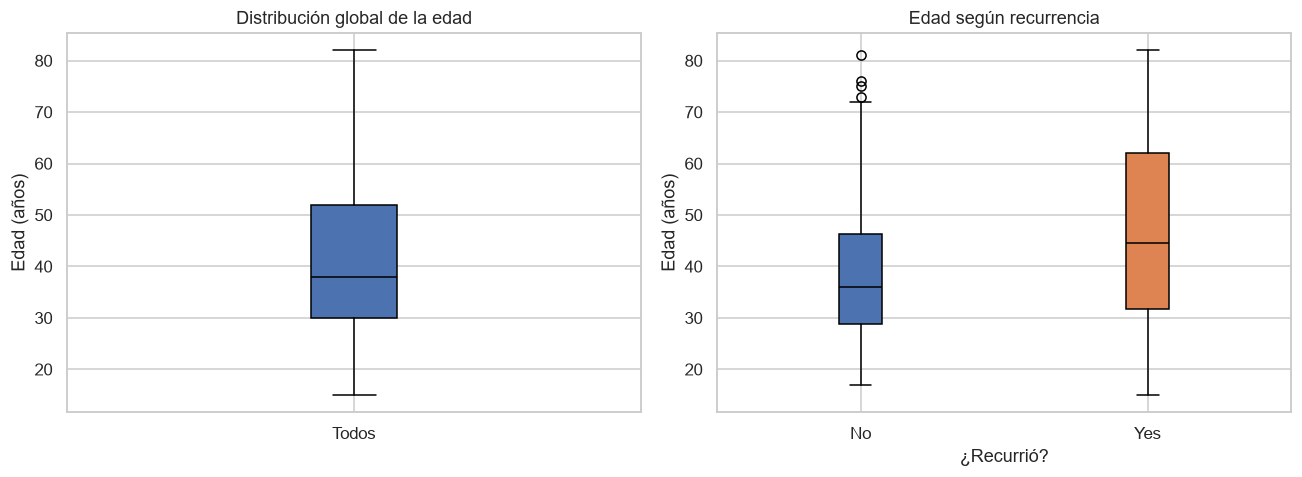

In [19]:
colores = sns.color_palette("deep", 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: distribución global de la edad
caja_g = axes[0].boxplot(df["Age"], patch_artist=True, tick_labels=["Todos"],
                         medianprops={"color": "black"})
caja_g["boxes"][0].set_facecolor(colores[0])
axes[0].set_title("Distribución global de la edad")
axes[0].set_ylabel("Edad (años)")

# Panel derecho: edad separada por recurrencia
grupos = ["No", "Yes"]
datos = [df.loc[df["Recurred"] == g, "Age"] for g in grupos]
caja_r = axes[1].boxplot(datos, patch_artist=True, tick_labels=grupos,
                         medianprops={"color": "black"})
for parche, color in zip(caja_r["boxes"], colores):
    parche.set_facecolor(color)
axes[1].set_title("Edad según recurrencia")
axes[1].set_xlabel("¿Recurrió?")
axes[1].set_ylabel("Edad (años)")

plt.tight_layout()
plt.show()


In [20]:
# Verificación de plausibilidad de los valores extremos
cols_ctx = ["Age", "Gender", "Pathology", "Risk", "Stage", "Response", "Recurred"]

print("Cinco edades más altas:")
display(df.nlargest(5, "Age")[cols_ctx])

print("Cinco edades más bajas:")
display(df.nsmallest(5, "Age")[cols_ctx])

print("Edades imposibles (negativas, cero o mayores a 120):",
      int(((df["Age"] <= 0) | (df["Age"] > 120)).sum()))


Cinco edades más altas:


,Age,Gender,Pathology,Risk,Stage,Response,Recurred
328,82,M,Papillary,Intermediate,II,Structural Incomplete,Yes
257,81,F,Papillary,Low,II,Excellent,No
360,81,M,Papillary,High,IVB,Structural Incomplete,Yes
301,80,F,Papillary,Intermediate,II,Structural Incomplete,Yes
343,80,F,Papillary,High,III,Structural Incomplete,Yes


Cinco edades más bajas:


,Age,Gender,Pathology,Risk,Stage,Response,Recurred
315,15,F,Papillary,Intermediate,I,Structural Incomplete,Yes
75,17,F,Papillary,Low,I,Excellent,No
188,17,F,Papillary,Intermediate,I,Indeterminate,No
207,17,F,Papillary,High,I,Structural Incomplete,Yes
84,18,F,Papillary,Intermediate,I,Structural Incomplete,Yes


Edades imposibles (negativas, cero o mayores a 120): 0


### Resultado sobre `Age`

**Global: Q1 = 30, Q3 = 52, IQR = 22, bigotes en [−3,0, 85,0] ⇒ 0 outliers.** Ninguna edad de la cohorte cae fuera del rango. El paciente de mayor edad tiene **82 años** y queda cómodamente dentro del bigote superior (85), y el más joven tiene **15**. El bigote inferior es negativo, lo que solo indica que la dispersión de la edad es amplia frente a su recorrido posible: por debajo no hay manera de ser atípico.

La verificación de plausibilidad lo confirma: **0 edades imposibles** —ningún valor negativo, ningún cero, nada por encima de 120— y las cinco edades más altas (82, 81, 81, 80, 80) y más bajas (15, 17, 17, 17, 18) son todas perfectamente compatibles con una cohorte de carcinoma diferenciado de tiroides, un tumor que aparece en un rango etario muy amplio y con incidencia notable en adultos jóvenes. No hay errores de captura que corregir.

### Lo que aporta el análisis estratificado

Aquí aparece el resultado más interesante del punto, y es uno que el análisis global no podía dar:

| Grupo | n | Media | Mediana | Desv. est. | Q1 | Q3 | IQR | Bigotes | Outliers |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Sin recurrencia | 256 | 38,78 | 36,0 | 13,16 | 28,75 | 46,25 | 17,50 | [2,5, 72,5] | **4** (73, 75, 76, 81) |
| Con recurrencia | 108 | 47,11 | 44,5 | 18,27 | 31,75 | 62,00 | 30,25 | [−13,6, 107,4] | 0 |

Los pacientes que recurren son **más de ocho años mayores en promedio** (47,11 frente a 38,78) y bastante más dispersos (desviación estándar 18,27 frente a 13,16). Ese mayor IQR —30,25 frente a 17,50— es exactamente lo que ensancha los bigotes del grupo con recurrencia hasta volverlos inalcanzables.

La consecuencia es reveladora: **el mismo valor de edad es atípico o normal según el grupo en el que se mire.** Un paciente de 75 años queda señalado como outlier entre los que no recurrieron, pero dentro del grupo que sí recurrió es una edad completamente ordinaria. Esos cuatro casos no tienen nada de anómalo como dato; lo que reflejan es que la edad avanzada es poco frecuente entre los pacientes de buen pronóstico —que es, precisamente, la relación clínica que el modelo debe aprender. Si se eliminaran «por atípicos» se estaría borrando la señal, no el ruido. Es un buen recordatorio de que el criterio IQR marca valores raros respecto de una distribución de referencia, y no errores; quién sea esa referencia cambia por completo el veredicto.


In [21]:
# Análogo categórico del outlier: categorías con muy baja frecuencia
col_cat = [c for c in df.columns if c != "Age"]

resumen_cat = []
for col in col_cat:
    vc = df[col].value_counts()
    resumen_cat.append({
        "columna": col,
        "n categorías": len(vc),
        "categoría menos frecuente": vc.index[-1],
        "n": int(vc.iloc[-1]),
        "% del total": round(vc.iloc[-1] / len(df) * 100, 2),
    })

display(pd.DataFrame(resumen_cat).sort_values("n").reset_index(drop=True))


,columna,n categorías,categoría menos frecuente,n,% del total
0,Adenopathy,6,Posterior,2,0.55
1,Stage,5,IVA,3,0.82
2,Thyroid Function,5,Subclinical Hyperthyroidism,5,1.37
3,Hx Radiotherapy,2,Yes,7,1.92
4,Physical Examination,5,Diffuse goiter,7,1.92
5,T,7,T4b,8,2.20
6,M,2,M1,18,4.95
7,Pathology,4,Hurthle cell,20,5.49
8,N,3,N1a,22,6.04
9,Response,4,Biochemical Incomplete,23,6.32


In [22]:
# Todas las categorías con menos de 10 registros, sin importar la columna
UMBRAL = 10

raras = []
for col in col_cat:
    vc = df[col].value_counts()
    for categoria, n in vc[vc < UMBRAL].items():
        raras.append({
            "columna": col,
            "categoría": categoria,
            "n": int(n),
            "% del total": round(n / len(df) * 100, 2),
        })

raras = pd.DataFrame(raras).sort_values("n").reset_index(drop=True)
display(raras)

print(f"Categorías con menos de {UMBRAL} registros:", len(raras))
print("Categoría más escasa:", raras.iloc[0]["columna"], "->",
      raras.iloc[0]["categoría"], f"({raras.iloc[0]['n']} registros)")


,columna,categoría,n,% del total
0,Adenopathy,Posterior,2,0.55
1,Stage,IVA,3,0.82
2,Stage,III,4,1.10
3,Thyroid Function,Subclinical Hyperthyroidism,5,1.37
4,Physical Examination,Diffuse goiter,7,1.92
5,Physical Examination,Normal,7,1.92
6,Adenopathy,Extensive,7,1.92
7,Hx Radiotherapy,Yes,7,1.92
8,T,T4b,8,2.20


Categorías con menos de 10 registros: 9
Categoría más escasa: Adenopathy -> Posterior (2 registros)


### Categorías raras: el equivalente categórico

Sobre las 364 filas limpias, **nueve categorías tienen menos de 10 registros**. Las críticas son:

| Columna | Categoría | n | % |
| --- | --- | --- | --- |
| `Adenopathy` | `Posterior` | 2 | 0,55 % |
| `Stage` | `IVA` | 3 | 0,82 % |
| `Stage` | `III` | 4 | 1,10 % |
| `Thyroid Function` | `Subclinical Hyperthyroidism` | 5 | 1,37 % |
| `Hx Radiotherapy` | `Yes` | 7 | 1,92 % |
| `Physical Examination` | `Normal` | 7 | 1,92 % |
| `Physical Examination` | `Diffuse goiter` | 7 | 1,92 % |
| `Adenopathy` | `Extensive` | 7 | 1,92 % |
| `T` | `T4b` | 8 | 2,20 % |

Justo por encima del umbral quedan otros dos casos que conviene vigilar: `Stage = IVB` (11 registros, 3,02 %) y `M = M1` (18 registros, 4,95 %).

### Decisión: se documentan, no se eliminan

**Ni las edades extremas ni las categorías raras se eliminan ni se recortan.** Se dejan tal como están y se registran aquí. Tres razones, en orden de peso:

1. **Son casos clínicos reales, no errores.** El criterio IQR y el conteo de frecuencias señalan valores *poco frecuentes*, que no es lo mismo que valores *equivocados*. La revisión de plausibilidad no encontró un solo dato imposible. Eliminar un registro correcto porque es infrecuente no limpia el conjunto: lo empobrece.

2. **Las categorías raras son precisamente los casos graves.** Esta es la razón de fondo. `M1` es metástasis a distancia; `Stage III`, `IVA` y `IVB` son los estadios avanzados; `T4b` es la invasión tumoral más extensa; `Adenopathy = Extensive` es el compromiso ganglionar más severo. Son escasas porque la enfermedad grave es escasa en esta cohorte —lo cual es una buena noticia clínica— pero son **exactamente los pacientes que más importa identificar** en un problema de recurrencia. Descartarlos por raros sería borrar la señal de alto riesgo y entrenar un modelo que solo ha visto pacientes de buen pronóstico: bueno en la métrica global y ciego justo donde el error cuesta más.

3. **Con 364 pacientes no hay margen.** Cualquier eliminación se paga cara, y el punto anterior implica que la mayoría de estas filas pertenecen a la clase minoritaria (108 casos de recurrencia). Cada una que se descartara empeoraría a la vez el tamaño de la muestra y el desbalance.

### Tres consecuencias metodológicas que se retoman más adelante

No eliminar tiene un precio, y es que estos casos escasos se vuelven un problema de *partición*, no de *limpieza*. Tres decisiones quedan condicionadas desde aquí:

1. **La partición debe ser estratificada por `Recurred`.** Con 108 casos positivos repartidos entre entrenamiento, validación y prueba, una partición aleatoria simple puede desviar notablemente la proporción en los conjuntos pequeños. `stratify=y` preserva el 70,33 / 29,67 en los tres, y sin eso las métricas de validación no serían comparables con las de prueba.

2. **El `OneHotEncoder` necesita `handle_unknown="ignore"`.** La estratificación protege el objetivo, pero **no** las categorías de las variables predictoras: con 2, 3 o 4 registros, es perfectamente posible que `Adenopathy = Posterior` o `Stage = IVA` no aparezcan en el conjunto de entrenamiento y sí en el de prueba. Un codificador ajustado sin ver esa categoría lanzaría una excepción en `transform` y rompería la evaluación. Con `handle_unknown="ignore"` la categoría desconocida se codifica como un vector de ceros: el modelo pierde esa información en ese registro concreto, que es un costo aceptable frente a un pipeline que se cae.

3. **La elección del escalador hay que sustentarla con evidencia.** Como no se recorta ningún valor extremo de `Age`, no se puede dar por sentado qué escalador conviene: la respuesta depende de si esa cola derecha llega o no a distorsionar la media y la desviación estándar, y eso hay que mirarlo en los datos. El Punto 10 hace precisamente esa comprobación y encuentra que, al no haber ningún outlier por el criterio IQR, el argumento habitual a favor de `RobustScaler` —su insensibilidad a los valores extremos— se queda sin nada que corregir, de modo que la diferencia práctica entre `StandardScaler` y `RobustScaler` resulta pequeña. La decisión se toma allí, con los percentiles de ambos a la vista.


## Punto 8 — Análisis exploratorio gráfico (EDA)

En esta sección se construyen las gráficas de EDA solicitadas: barras, pie, histograma, scatter plot y boxplot, sobre las 364 filas que quedaron tras la depuración de los puntos anteriores.

El dataset tiene una particularidad que condiciona todo el recorrido: de las 17 columnas, **16 son categóricas y solo una es numérica** (`Age`). Esto implica dos cosas. Primera, que la familia de barras es aquí la herramienta principal de exploración y no un complemento decorativo. Segunda, que el scatter plot clásico entre dos variables numéricas es imposible en este conjunto, y hay que resolverlo con una codificación ordinal que se explica y se justifica en el apartado 8.7.

Un criterio transversal a toda la sección: cuando se comparan categorías de tamaños muy distintos, **el conteo bruto engaña y lo informativo es la tasa**. Un grupo pequeño con recurrencia altísima casi no se ve en un gráfico de frecuencias, pero es exactamente el grupo que interesa clínicamente. Por eso la mayoría de las barras de este punto muestran el porcentaje de pacientes con `Recurred = "Yes"` dentro de cada categoría, acompañado siempre del `n` sobre el que se calcula, para poder juzgar la confiabilidad de cada estimación.

Cada gráfica va seguida de un párrafo de interpretación con su lectura clínica y una recomendación explícita formulada como responsable de la toma de decisiones.


### 8.1 — Barras: distribución del target `Recurred`

Se empieza por la variable objetivo. Antes de cualquier análisis de asociación hay que saber cuántos pacientes recurren, porque de ese balance dependen tanto la interpretación de las tasas posteriores como las decisiones de modelado del taller.


,Recurred,pacientes,porcentaje
0,No,256,70.33
1,Yes,108,29.67


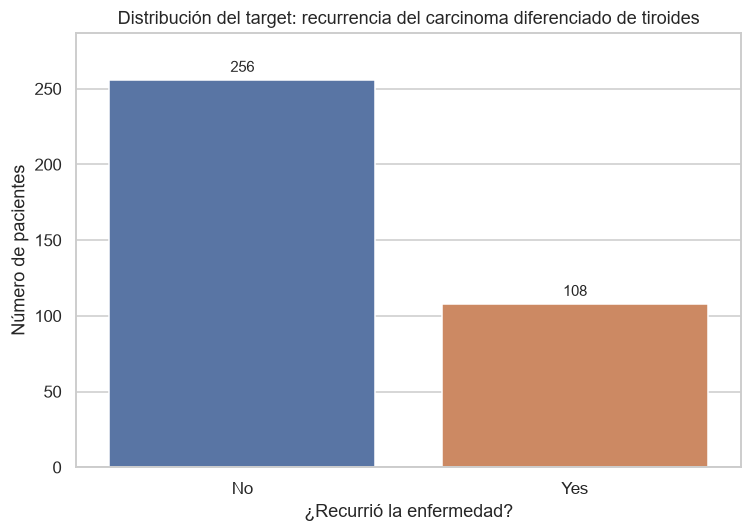

In [23]:
# Función auxiliar reutilizada en todo el punto 8:
# devuelve n, casos con recurrencia y tasa (%) por categoría de una variable.
def tasa_recurrencia(col, orden=None):
    t = (
        df.groupby(col, observed=True)["Recurred"]
          .agg(n="size", recurre=lambda s: (s == "Yes").sum())
    )
    t["tasa_%"] = (t["recurre"] / t["n"] * 100).round(1)
    return t.reindex(orden) if orden is not None else t


conteo_target = (
    df["Recurred"].value_counts()
      .reindex(["No", "Yes"])
      .rename_axis("Recurred")
      .reset_index(name="pacientes")
)
conteo_target["porcentaje"] = (conteo_target["pacientes"] / len(df) * 100).round(2)
display(conteo_target)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=conteo_target, x="Recurred", y="pacientes",
    hue="Recurred", palette="deep", legend=False, ax=ax,
)
for cont in ax.containers:
    ax.bar_label(cont, fmt="{:.0f}", padding=3, fontsize=10)

ax.set_title("Distribución del target: recurrencia del carcinoma diferenciado de tiroides")
ax.set_xlabel("¿Recurrió la enfermedad?")
ax.set_ylabel("Número de pacientes")
ax.margins(y=0.12)
plt.tight_layout()
plt.show()


**Interpretación.** De los 364 pacientes de la cohorte depurada, 256 (70,33 %) no presentaron recurrencia y 108 (29,67 %) sí. La clase positiva es entonces minoritaria, en una proporción cercana a 7:3. No es un desbalance extremo como el de un problema de fraude, pero es suficiente para que un clasificador que prediga siempre "No" alcance un 70,33 % de exactitud sin haber aprendido absolutamente nada.

Clínicamente la cifra es coherente con lo que se espera del carcinoma diferenciado de tiroides: es un tumor de pronóstico favorable, con supervivencia alta y recurrencia relativamente infrecuente, pero ese casi 30 % de recaídas no es despreciable y es justamente lo que justifica los protocolos de seguimiento prolongado. El problema real de la práctica clínica no es detectar que la mayoría está bien, sino identificar a tiempo a esa minoría que recae.

**Recomendación.** Como responsable de la toma de decisiones, se recomienda **fijar desde ya que la exactitud (accuracy) no será la métrica de evaluación del modelo**. El umbral de referencia de un clasificador trivial es 70,33 %, de modo que cualquier resultado cercano a esa cifra debe leerse como fracaso y no como éxito. Se recomienda evaluar con recall y F1 sobre la clase "Yes" y con la matriz de confusión, y **priorizar explícitamente la sensibilidad**: en seguimiento oncológico el costo de un falso negativo (dar de alta a un paciente que va a recaer) es muy superior al de un falso positivo (un control adicional innecesario). Se recomienda además estratificar por `Recurred` toda partición entre entrenamiento y prueba, para no acabar con conjuntos que alteren esta proporción por azar.


### 8.2 — Barras: tasa de recurrencia por variable clínica de estadificación

Aquí está el núcleo del EDA. Se calcula el porcentaje de pacientes con recurrencia dentro de cada categoría de cuatro variables clínicas clave: `Risk` (clasificación de riesgo de la ATA), `N` (compromiso ganglionar), `T` (extensión del tumor primario) y `Response` (respuesta al tratamiento inicial).

Se grafica la **tasa** y no el conteo por una razón deliberada: las categorías tienen tamaños muy dispares. Por ejemplo `Risk = "Low"` reúne 230 pacientes y `Risk = "High"` apenas 32. En un gráfico de frecuencias la barra de "High" sería casi invisible pese a ser el grupo de mayor gravedad, mientras que la tasa pone a las categorías en una escala comparable, de 0 a 100 %, con independencia de su tamaño. El `n` de cada grupo se conserva en las tablas impresas para poder juzgar cuán confiable es cada porcentaje.

Las barras se ordenan según la progresión clínica natural de cada variable, no por magnitud, para que la lectura del gradiente sea inmediata.


--- Tasa de recurrencia por Risk ---


,Risk,n,recurre,tasa_%
0,Low,230,12,5.2
1,Intermediate,102,64,62.7
2,High,32,32,100.0


--- Tasa de recurrencia por N ---


,N,n,recurre,tasa_%
0,N0,249,27,10.8
1,N1a,22,10,45.5
2,N1b,93,71,76.3


--- Tasa de recurrencia por T ---


,T,n,recurre,tasa_%
0,T1a,46,1,2.2
1,T1b,40,5,12.5
2,T2,138,20,14.5
3,T3a,96,41,42.7
4,T3b,16,14,87.5
5,T4a,20,19,95.0
6,T4b,8,8,100.0


--- Tasa de recurrencia por Response ---


,Response,n,recurre,tasa_%
0,Excellent,189,1,0.5
1,Indeterminate,61,7,11.5
2,Biochemical Incomplete,23,11,47.8
3,Structural Incomplete,91,89,97.8


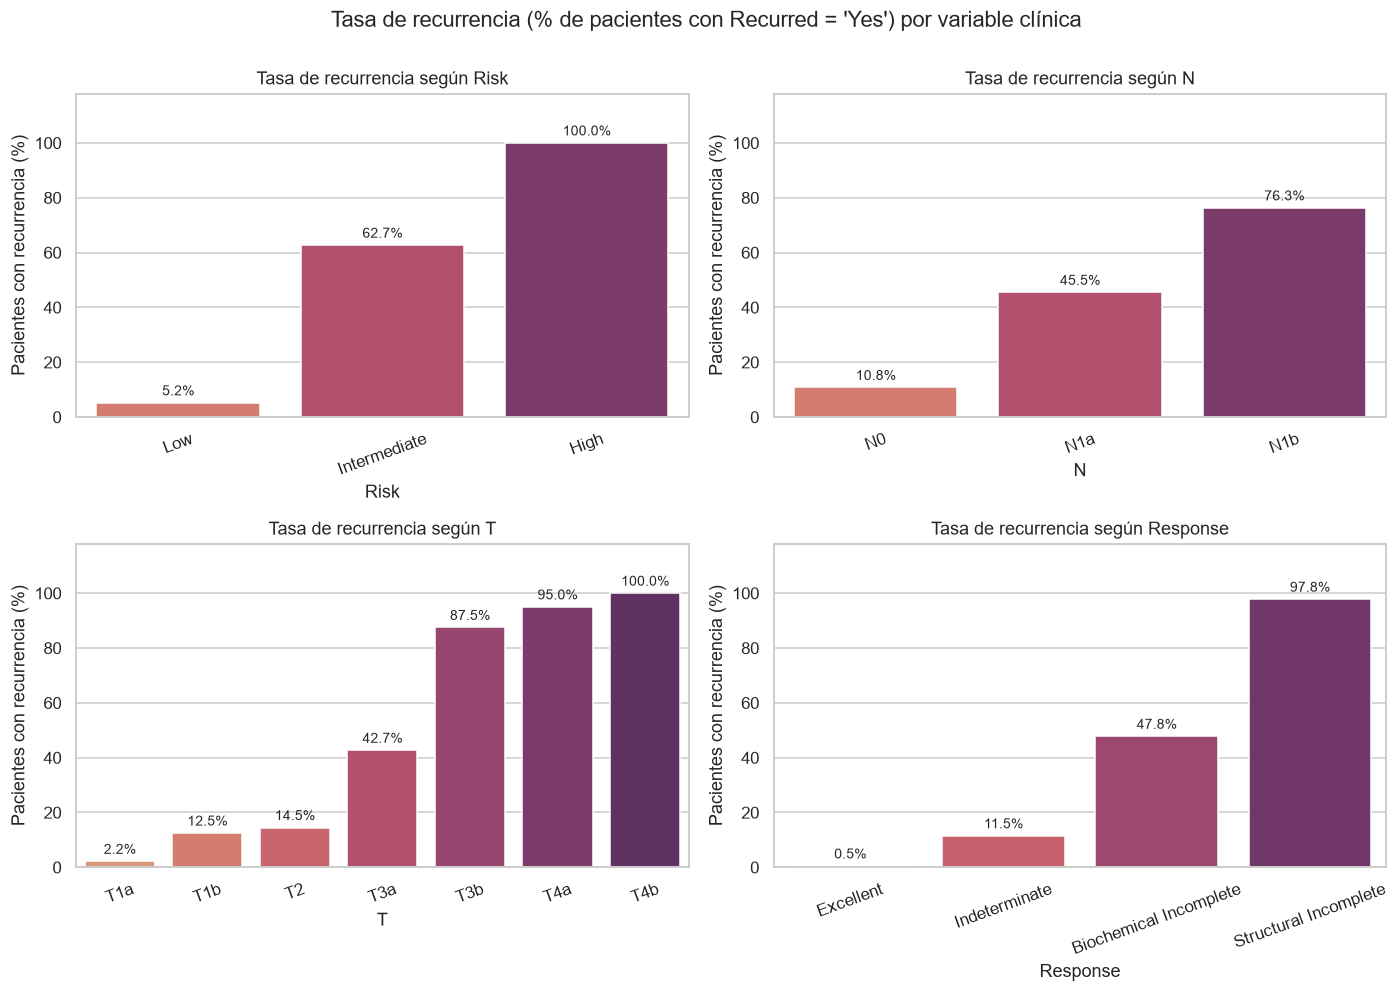

In [24]:
ordenes = {
    "Risk": ["Low", "Intermediate", "High"],
    "N": ["N0", "N1a", "N1b"],
    "T": ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"],
    "Response": ["Excellent", "Indeterminate", "Biochemical Incomplete", "Structural Incomplete"],
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, orden) in zip(axes.ravel(), ordenes.items()):
    t = tasa_recurrencia(col, orden).reset_index()
    print(f"--- Tasa de recurrencia por {col} ---")
    display(t)

    sns.barplot(
        data=t, x=col, y="tasa_%",
        hue=col, palette="flare", legend=False, order=orden, ax=ax,
    )
    for cont in ax.containers:
        ax.bar_label(cont, fmt="{:.1f}%", padding=3, fontsize=9)

    ax.set_title(f"Tasa de recurrencia según {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Pacientes con recurrencia (%)")
    ax.set_ylim(0, 118)
    ax.tick_params(axis="x", labelrotation=20)

fig.suptitle("Tasa de recurrencia (% de pacientes con Recurred = 'Yes') por variable clínica", y=1.0)
plt.tight_layout()
plt.show()


**Interpretación.** Las cuatro variables muestran un gradiente monótono, es decir, la tasa de recurrencia sube de forma sostenida a medida que avanza la gravedad clínica. No hay ninguna inversión ni ningún escalón caprichoso, lo que refuerza la idea de que estas asociaciones son reales y no ruido muestral.

- `Risk` es la variable con el gradiente más limpio de todo el dataset: 5,2 % de recurrencia en riesgo bajo (12 de 230), 62,7 % en riesgo intermedio (64 de 102) y 100 % en riesgo alto (32 de 32). El salto entre "Low" e "Intermediate" es de más de doce veces.
- `N` (compromiso ganglionar) va de 10,8 % en N0 a 45,5 % en N1a y 76,3 % en N1b. La lectura clínica es directa: la afectación de ganglios laterocervicales (N1b) multiplica por siete el riesgo respecto de un cuello negativo.
- `T` va de 2,2 % en T1a a 100 % en T4b, con un punto de inflexión muy marcado entre T2 (14,5 %) y T3a (42,7 %). La extensión extratiroidea marca un antes y un después.
- `Response` es la más discriminante de las cuatro: 0,5 % en respuesta excelente (1 caso entre 189) frente a 97,8 % en respuesta estructural incompleta (89 de 91). Prácticamente separa la cohorte en dos.

**Advertencia estadística importante.** Varias de estas tasas del 100 % descansan sobre muy pocos pacientes. `T4b` tiene 8 casos y `T3b` tiene 16; `Risk = "High"` tiene 32. Un 100 % calculado sobre 8 observaciones no es una estimación confiable: el intervalo de confianza asociado es amplísimo y basta un solo paciente distinto para moverla varios puntos. Lo que estas barras sostienen razonablemente es la **dirección** del efecto (más estadio, más recurrencia), no el valor puntual del porcentaje. Este mismo cuidado aplica más adelante a `Stage III`, con apenas 4 pacientes.

**Significado clínico y recomendación.** El hallazgo sobre `Response` merece una lectura aparte y una decisión explícita. La respuesta al tratamiento inicial no es una característica del paciente en el momento del diagnóstico: es una evaluación **posterior** a la cirugía y a la ablación. Si el objetivo es predecir la recurrencia en el momento del diagnóstico, incluir `Response` es fuga de información (data leakage), porque el modelo estaría usando una variable medida después del desenlace que se quiere anticipar y que además es casi una definición operativa del mismo.

Como responsable de la toma de decisiones, se recomienda por tanto **construir dos escenarios de modelado y no uno solo**: (a) un modelo pronóstico "al diagnóstico", que excluya `Response` y se apoye en `Risk`, `T`, `N`, `M`, `Focality` y `Adenopathy`, útil para decidir la intensidad del seguimiento cuando el paciente todavía no ha sido tratado; y (b) un modelo de seguimiento que sí incluya `Response`, aplicable en la consulta de control posterior. Se recomienda además, en el plano asistencial, **asignar seguimiento intensificado a todo paciente con `Risk` alto o intermedio, N1b o respuesta estructural incompleta**, y no reportar nunca las tasas de las categorías pequeñas sin acompañarlas del `n`, para no transmitir a un comité clínico una falsa sensación de certeza.


### 8.3 — Barras agrupadas: `Gender` frente a `Recurred`

Se examina ahora una variable demográfica. El cáncer de tiroides tiene una incidencia marcadamente mayor en mujeres, y conviene verificar si esa asimetría de la cohorte se traduce también en una diferencia de pronóstico. Se muestran en paralelo los conteos absolutos y las tasas, precisamente para ilustrar cómo cada representación cuenta una historia distinta.


Recurred,No,Yes
Gender,,
F,227,66
M,29,42


,Gender,n,recurre,tasa_%
0,F,293,66,22.5
1,M,71,42,59.2


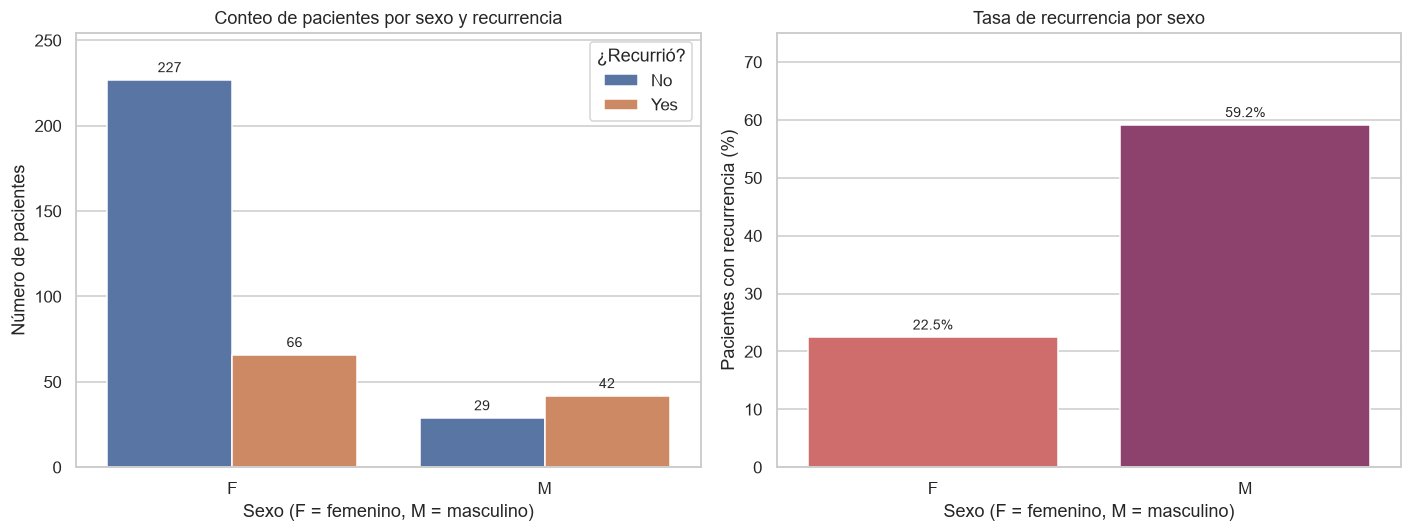

In [25]:
gen_tab = pd.crosstab(df["Gender"], df["Recurred"])
display(gen_tab)

gen_long = gen_tab.reset_index().melt(
    id_vars="Gender", var_name="Recurred", value_name="pacientes"
)
gen_tasa = tasa_recurrencia("Gender").reset_index()
display(gen_tasa)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=gen_long, x="Gender", y="pacientes",
    hue="Recurred", palette="deep", ax=axes[0],
)
for cont in axes[0].containers:
    axes[0].bar_label(cont, fmt="{:.0f}", padding=3, fontsize=9)
axes[0].set_title("Conteo de pacientes por sexo y recurrencia")
axes[0].set_xlabel("Sexo (F = femenino, M = masculino)")
axes[0].set_ylabel("Número de pacientes")
axes[0].legend(title="¿Recurrió?")
axes[0].margins(y=0.12)

sns.barplot(
    data=gen_tasa, x="Gender", y="tasa_%",
    hue="Gender", palette="flare", legend=False, ax=axes[1],
)
for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt="{:.1f}%", padding=3, fontsize=9)
axes[1].set_title("Tasa de recurrencia por sexo")
axes[1].set_xlabel("Sexo (F = femenino, M = masculino)")
axes[1].set_ylabel("Pacientes con recurrencia (%)")
axes[1].set_ylim(0, 75)

plt.tight_layout()
plt.show()


**Interpretación.** Los dos paneles muestran los mismos datos y sugieren conclusiones opuestas si se leen sin cuidado. El panel de conteos está dominado por las mujeres: 293 pacientes frente a 71 hombres, y la barra más alta de recurrencias corresponde a mujeres (66 casos frente a 42). Alguien que solo mirara ese panel podría concluir que la recurrencia es "un problema de mujeres". El panel de tasas invierte la lectura: la recurrencia afecta al 22,5 % de las mujeres (66 de 293) y al 59,2 % de los hombres (42 de 71), es decir, **más del doble en hombres**.

La aparente contradicción no lo es: las mujeres aportan más casos de recurrencia en términos absolutos simplemente porque son cuatro veces más numerosas en la cohorte, mientras que el riesgo individual es claramente mayor en los hombres. Este contraste es el mejor argumento a favor del criterio metodológico anunciado al comienzo del punto: cuando los grupos tienen tamaños muy distintos, comparar alturas de barras de frecuencia es comparar tamaños de población y no riesgos. Clínicamente, el resultado es consistente con la literatura del carcinoma diferenciado de tiroides, donde el sexo masculino se reconoce como factor de peor pronóstico pese a la menor incidencia.

Conviene mantener una reserva: el sexo podría estar actuando como variable indirecta (proxy) de otras características, si por ejemplo los hombres de esta cohorte se diagnosticaran en estadios más avanzados o a mayor edad. La gráfica por sí sola no permite separar el efecto propio del sexo del efecto de la gravedad al diagnóstico.

**Recomendación.** Se recomienda **conservar `Gender` como predictor del modelo** y, en el plano clínico, **no aplicar el mismo protocolo de seguimiento a hombres y mujeres con idéntica clasificación de riesgo**: los datos de esta cohorte sostienen una vigilancia más estrecha en pacientes de sexo masculino. Se recomienda además, antes de convertir esto en una regla asistencial, **verificar con una tabla cruzada de `Gender` contra `Risk` y `Stage` si la diferencia persiste al controlar por gravedad al diagnóstico**, para no atribuir al sexo un efecto que en realidad pertenezca al estadio.


### 8.4 — Gráficos de pie: composición del target y de `Pathology`

Se representa la distribución del target y la del tipo histológico como partes de un todo. El gráfico de pie tiene limitaciones conocidas y bien documentadas: el ojo humano compara longitudes con mucha mayor precisión que ángulos o áreas, de modo que con muchas categorías o con proporciones parecidas resulta claramente inferior a un gráfico de barras, y además no permite leer valores absolutos ni comparar cómodamente entre dos gráficos distintos.

Su uso aquí es deliberado y acotado: ambas variables tienen pocas categorías (dos y cuatro), son mutuamente excluyentes y agotan el total, y lo que interesa comunicar es exactamente la idea de "proporción del total" y no una comparación fina entre categorías. Es el caso concreto en el que el pie sí resulta adecuado. Se anotan los porcentajes con `autopct` y se incluye el `n` en las etiquetas para compensar la limitación de no mostrar valores absolutos.


,pacientes,porcentaje
Pathology,,
Papillary,271,74.5
Micropapillary,45,12.4
Follicular,28,7.7
Hurthle cell,20,5.5


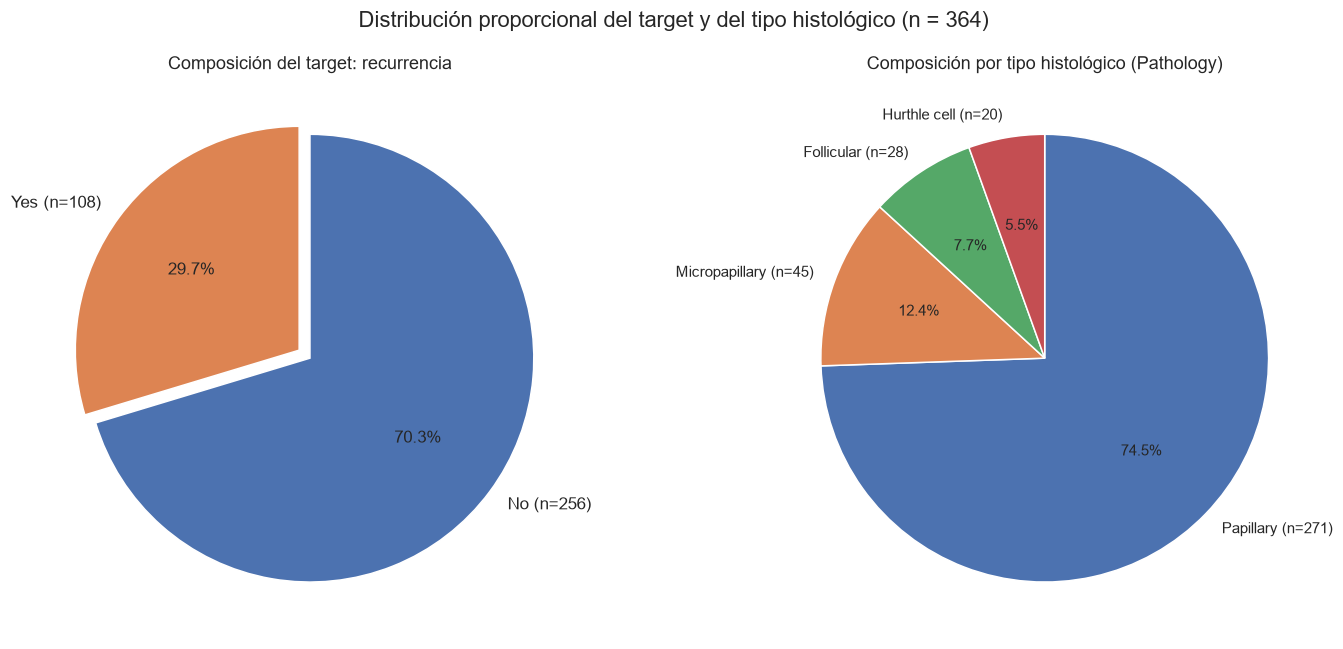

In [26]:
conteo_rec = df["Recurred"].value_counts().reindex(["No", "Yes"])
conteo_pat = df["Pathology"].value_counts()
display(pd.DataFrame({"pacientes": conteo_pat,
                      "porcentaje": (conteo_pat / len(df) * 100).round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].pie(
    conteo_rec.values,
    labels=[f"{k} (n={v})" for k, v in conteo_rec.items()],
    autopct="%1.1f%%", startangle=90, counterclock=False,
    colors=sns.color_palette("deep", 2), explode=(0, 0.06),
    textprops={"fontsize": 11},
)
axes[0].set_title("Composición del target: recurrencia")

axes[1].pie(
    conteo_pat.values,
    labels=[f"{k} (n={v})" for k, v in conteo_pat.items()],
    autopct="%1.1f%%", startangle=90, counterclock=False,
    colors=sns.color_palette("deep", len(conteo_pat)),
    textprops={"fontsize": 10},
)
axes[1].set_title("Composición por tipo histológico (Pathology)")

fig.suptitle("Distribución proporcional del target y del tipo histológico (n = 364)")
plt.tight_layout()
plt.show()


**Interpretación.** El primer pie confirma visualmente el desbalance del target: 70,3 % de pacientes sin recurrencia frente a 29,7 % con recurrencia. Al ser solo dos porciones, la comparación de ángulos es inmediata y no hay pérdida de legibilidad.

El segundo pie muestra que la cohorte está fuertemente dominada por un único tipo histológico: el carcinoma papilar concentra 271 pacientes (74,5 %), seguido del micropapilar con 45 (12,4 %), el folicular con 28 (7,7 %) y el de células de Hürthle con 20 (5,5 %). Esta composición es la esperable en una cohorte de carcinoma diferenciado de tiroides, donde el papilar es con diferencia la variante más frecuente, pero tiene una consecuencia práctica incómoda: las tres categorías minoritarias suman apenas 93 pacientes entre las tres, y cualquier estimación de recurrencia específica para el subtipo de células de Hürthle descansaría sobre 20 observaciones. De nuevo, el `n` limita lo que se puede afirmar con confianza, incluso cuando el porcentaje parece contundente.

Vale la pena señalar una limitación del propio gráfico: entre el folicular (7,7 %) y el de Hürthle (5,5 %) la diferencia de ángulo es casi imperceptible a simple vista, y solo la anotación numérica permite distinguirlas. Es precisamente el punto en que el pie empieza a fallar y en el que unas barras habrían sido superiores.

**Recomendación.** Se recomienda **no construir modelos ni protocolos específicos por subtipo histológico minoritario con esta cohorte**, porque el tamaño muestral de las tres categorías pequeñas no lo sustenta; conviene tratar `Pathology` como un predictor más dentro del modelo global, y evaluar en la fase de codificación si las categorías de menor frecuencia deben agruparse para estabilizar el aprendizaje. En el plano de la comunicación de resultados, se recomienda **reservar el pie para la presentación del desbalance del target ante públicos no técnicos y usar barras para todo análisis comparativo**, dado que la comparación de ángulos deja de ser fiable en cuanto hay más de tres o cuatro categorías.


### 8.5 — Histograma: distribución de la edad

`Age` es la única variable numérica del dataset, de modo que es la única candidata a un histograma en sentido estricto. Se marca la mediana con una línea vertical de referencia, por ser el estadístico de posición robusto y coherente con la asimetría detectada en el análisis descriptivo.


count    364.00
mean      41.25
std       15.31
min       15.00
25%       30.00
50%       38.00
75%       52.00
max       82.00
Name: Age, dtype: float64

Asimetría (skew) de Age: 0.678


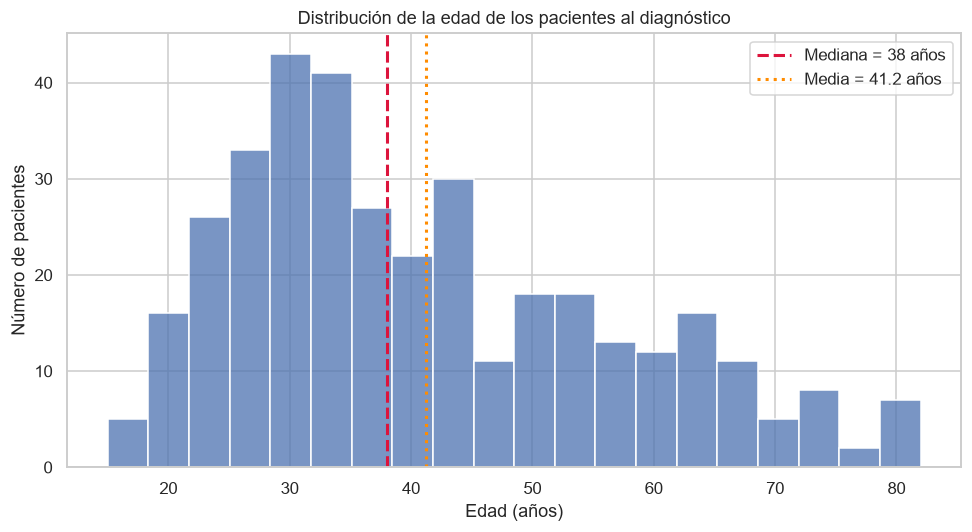

In [27]:
edad_desc = df["Age"].describe().round(2)
display(edad_desc)
print(f"Asimetría (skew) de Age: {df['Age'].skew():.3f}")

mediana_edad = df["Age"].median()
media_edad = df["Age"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x="Age", bins=20, color=sns.color_palette("deep")[0],
             edgecolor="white", ax=ax)
ax.axvline(mediana_edad, color="crimson", linestyle="--", linewidth=2,
           label=f"Mediana = {mediana_edad:.0f} años")
ax.axvline(media_edad, color="darkorange", linestyle=":", linewidth=2,
           label=f"Media = {media_edad:.1f} años")

ax.set_title("Distribución de la edad de los pacientes al diagnóstico")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Número de pacientes")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación.** La distribución de la edad se concentra entre los 15 y los 82 años, con una mediana de 38 años, una media de 41,25 y un rango intercuartílico que va de 30 a 52 años. La media queda por encima de la mediana y el coeficiente de asimetría es de 0,678, lo que confirma una **asimetría positiva moderada**: el grueso de los pacientes es joven y hay una cola que se extiende hacia las edades avanzadas, sin que aparezca ningún segundo pico ni ninguna forma bimodal.

Clínicamente el perfil encaja con lo conocido del carcinoma diferenciado de tiroides, que a diferencia de la mayoría de tumores sólidos se diagnostica con frecuencia en adultos jóvenes y en edad productiva. Esto tiene una implicación asistencial de fondo: se trata de pacientes que van a vivir muchas décadas después del diagnóstico y que, por tanto, van a acumular un riesgo de recurrencia a lo largo de un horizonte de seguimiento muy largo.

Conviene subrayar que la asimetría observada es moderada y no problemática. No hay valores imposibles ni registros centinela del tipo 0, 999 o negativos, y ambos extremos —15 y 82 años— son edades perfectamente plausibles para esta patología.

**Recomendación.** Se recomienda **conservar `Age` en su escala original, sin transformación logarítmica ni recorte de la cola**: una asimetría de 0,678 no justifica intervenir la variable, y transformarla solo dificultaría la interpretación clínica de los resultados sin ganancia apreciable. Para modelos sensibles a la escala, como la regresión logística regularizada o el k-NN, se recomienda estandarizar la variable dentro del pipeline y **ajustando el escalador únicamente sobre el conjunto de entrenamiento**, para no filtrar información del conjunto de prueba. La decisión sobre valores extremos se retoma con evidencia gráfica en el apartado 8.8.


### 8.6 — Histogramas superpuestos: edad según recurrencia

Se compara la distribución de la edad entre quienes recurrieron y quienes no, usando `hue` para superponer ambas distribuciones sobre el mismo eje. La pregunta que se quiere responder es si la edad, por sí sola, permitiría separar a los dos grupos.


,n,media,mediana,desv,minimo,maximo
Recurred,,,,,,
No,256,38.78,36.0,13.16,17,81
Yes,108,47.11,44.5,18.27,15,82


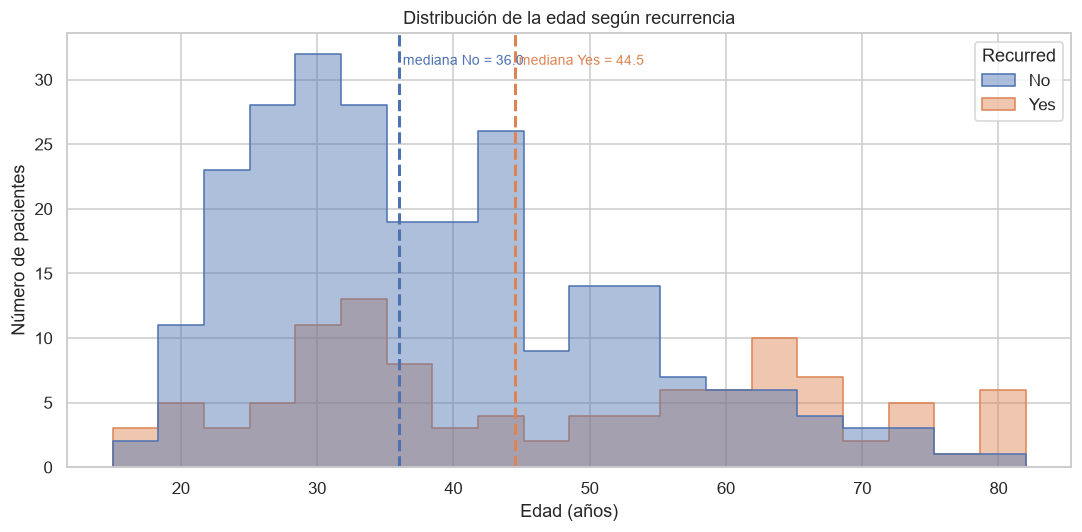

In [28]:
comp_edad = (
    df.groupby("Recurred", observed=True)["Age"]
      .agg(n="size", media="mean", mediana="median", desv="std", minimo="min", maximo="max")
      .round(2)
)
display(comp_edad)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=df, x="Age", hue="Recurred", bins=20,
    multiple="layer", element="step", alpha=0.45,
    palette="deep", ax=ax,
)
for etiqueta, color in zip(["No", "Yes"], sns.color_palette("deep", 2)):
    med = df.loc[df["Recurred"] == etiqueta, "Age"].median()
    ax.axvline(med, color=color, linestyle="--", linewidth=2)
    ax.text(med, ax.get_ylim()[1] * 0.95, f" mediana {etiqueta} = {med:.1f}",
            color=color, fontsize=9, va="top")

ax.set_title("Distribución de la edad según recurrencia")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Número de pacientes")
plt.tight_layout()
plt.show()


**Interpretación.** Las dos distribuciones están desplazadas pero **ampliamente solapadas**. Los pacientes sin recurrencia (n = 256) tienen una media de 38,78 años y una mediana de 36, mientras que los que recurrieron (n = 108) tienen media 47,11 y mediana 44,5: una diferencia de 8,33 años en la media. El grupo con recurrencia es además notablemente más disperso (desviación estándar 18,27 frente a 13,16) y su histograma es visiblemente más plano, con presencia apreciable de pacientes por encima de los 60 años, franja en la que el grupo sin recurrencia casi desaparece.

Ahora bien, los rangos son prácticamente idénticos —17 a 81 años en el grupo sin recurrencia, 15 a 82 en el grupo con recurrencia— y en la zona central, entre los 30 y los 50 años, ambas curvas se montan una sobre otra casi por completo. La consecuencia es clara y merece enunciarse sin ambigüedad: **la edad desplaza el riesgo pero no separa a los grupos**. No existe ningún punto de corte de edad que clasifique correctamente a los pacientes, y cualquier regla del tipo "por encima de X años el paciente recurre" produciría un número inaceptable de errores en ambas direcciones. Esto es consistente con el conocimiento clínico, donde la edad es un factor pronóstico reconocido y forma parte de los sistemas de estadificación, pero nunca como criterio aislado.

**Recomendación.** Se recomienda **incluir `Age` en el modelo como predictor auxiliar y no como criterio de decisión clínica por sí solo**. En términos asistenciales, conviene **no relajar el seguimiento de un paciente joven apoyándose en su edad**, porque el solapamiento de las distribuciones muestra que hay recurrencias en todo el rango etario, desde los 15 años; la edad debe pesar en la decisión solo en combinación con las variables de estadificación, que son las que sí discriminan. Para el modelado se recomienda **no discretizar la edad en rangos arbitrarios**, porque un corte elegido a ojo sobre este histograma perdería información sin ganancia alguna. Conviene precisar el alcance de esta gráfica: muestra que la *distribución* de la edad es unimodal y sin cortes naturales, lo que no equivale a demostrar que el *riesgo* crezca de forma suave con la edad. Esa segunda pregunta requiere cruzar la edad con el target controlando por gravedad, y se examina en el apartado 8.7, donde el resultado obliga a matizar la lectura simple de "a más edad, más riesgo".


### 8.7 — Scatter plot: edad frente a estadio clínico

**Limitación del dataset y cómo se resuelve.** El scatter plot clásico exige dos variables numéricas continuas, una por eje, y este dataset **solo tiene una** (`Age`); las otras dieciséis columnas son categóricas. Un scatter en sentido estricto es por tanto imposible aquí, y conviene decirlo antes que forzar una gráfica que no significa nada.

La salida adoptada es codificar una variable clínica **ordinal** —el estadio `Stage`, cuyas categorías I, II, III, IVA y IVB tienen un orden real de gravedad— como los enteros 0 a 4, y usarla como eje vertical frente a la edad en el eje horizontal. La codificación no es arbitraria: respeta el orden clínico y por eso la posición vertical de un punto sigue siendo interpretable.

Persiste un problema de visualización: al ser el eje Y discreto, todos los pacientes de un mismo estadio caerían exactamente sobre la misma línea horizontal y los puntos se apilarían unos sobre otros, ocultando la densidad real (un solo punto visible podría estar tapando veinte). Para evitarlo se añade **jitter**, un pequeño desplazamiento vertical aleatorio de desviación 0,08 que separa los puntos superpuestos sin cambiar su estadio aparente. El generador se fija con semilla 42 para que la figura sea reproducible. Debe recordarse al leer la gráfica que **la dispersión vertical dentro de cada banda es ruido añadido y no información**: la única información vertical es a qué banda pertenece el punto.

Como vista complementaria se acompaña de un `stripplot` de la edad por nivel de riesgo, que conserva la naturaleza categórica del eje sin necesidad de codificación.


,n,recurre,tasa_%
Stage,,,
I,314,65,20.7
II,32,25,78.1
III,4,4,100.0
IVA,3,3,100.0
IVB,11,11,100.0


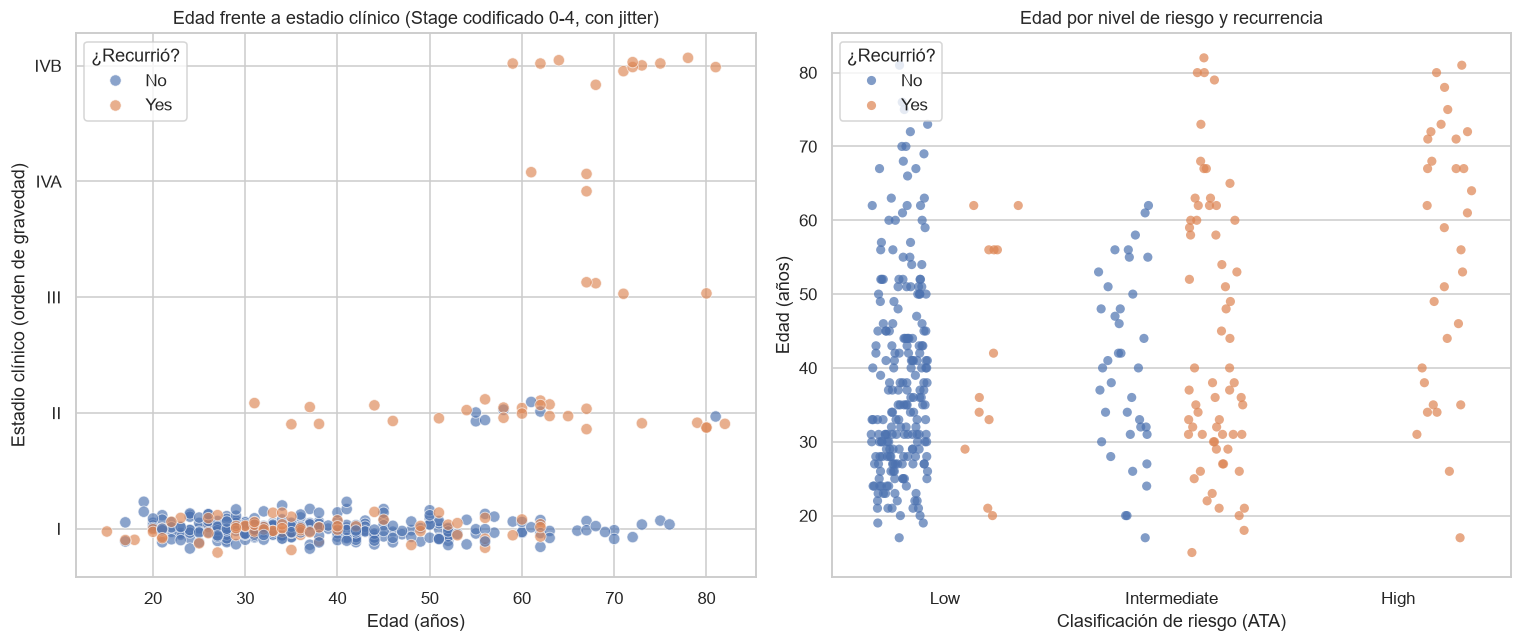

In [29]:
orden_stage = ["I", "II", "III", "IVA", "IVB"]
mapa_stage = {etq: i for i, etq in enumerate(orden_stage)}

rng = np.random.default_rng(42)
vista = df[["Age", "Stage", "Risk", "Recurred"]].copy()
vista["stage_cod"] = vista["Stage"].map(mapa_stage)
vista["stage_jitter"] = vista["stage_cod"] + rng.normal(0, 0.08, len(vista))

display(tasa_recurrencia("Stage", orden_stage))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=vista, x="Age", y="stage_jitter", hue="Recurred",
    palette="deep", alpha=0.65, s=55, edgecolor="white", ax=axes[0],
)
axes[0].set_yticks(range(len(orden_stage)))
axes[0].set_yticklabels(orden_stage)
axes[0].set_title("Edad frente a estadio clínico (Stage codificado 0-4, con jitter)")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Estadio clínico (orden de gravedad)")
axes[0].legend(title="¿Recurrió?", loc="upper left")

sns.stripplot(
    data=df, x="Risk", y="Age", hue="Recurred",
    order=["Low", "Intermediate", "High"], dodge=True,
    palette="deep", alpha=0.7, size=6, jitter=0.25, ax=axes[1],
)
axes[1].set_title("Edad por nivel de riesgo y recurrencia")
axes[1].set_xlabel("Clasificación de riesgo (ATA)")
axes[1].set_ylabel("Edad (años)")
axes[1].legend(title="¿Recurrió?", loc="upper left")

plt.tight_layout()
plt.show()


**Interpretación.** El panel izquierdo muestra una estructura muy marcada. El estadio I concentra la enorme mayoría de la cohorte (314 de 364 pacientes) y se extiende sobre todo el rango de edad, mientras que a partir del estadio II los puntos se desplazan en bloque hacia la derecha y casi todos son recurrencias: en los estadios III, IVA y IVB **no aparece un solo paciente de la clase "No" ni ninguno por debajo de los 59 años** (las edades mínimas observadas son 67, 61 y 59 años respectivamente).

Antes de dar por bueno este hallazgo hay que preguntarse de dónde viene, porque la gráfica invita a una conclusión que no se sostiene. En el sistema de estadificación AJCC del carcinoma diferenciado de tiroides **la edad del paciente entra como criterio para asignar el estadio**, con un umbral situado en los 55 años. La asociación entre edad y estadio no es entonces un hallazgo empírico independiente, sino en buena medida una consecuencia de cómo está construida la variable. La comprobación es directa y contundente: **dentro del estadio I, la tasa de recurrencia es del 22,8 % entre los pacientes de 20 a 40 años y del 22,2 % entre los de 55 años o más**, es decir, prácticamente idéntica. Una vez fijado el estadio, la edad deja de aportar información.

Las tasas por estadio son I 20,7 % (65 de 314), II 78,1 % (25 de 32), III 100 % (4 de 4), IVA 100 % (3 de 3) y IVB 100 % (11 de 11). Hay que insistir en la advertencia estadística: **un 100 % calculado sobre 4 pacientes en el estadio III, o sobre 3 en el IVA, no es una estimación confiable en absoluto**. Con muestras de ese tamaño, un solo caso distinto cambiaría el porcentaje en 25 o 33 puntos. Estas celdas indican dirección y gravedad, no una probabilidad de recurrencia que pueda comunicarse a un paciente.

El panel derecho permite repetir la comprobación sobre `Risk`, que a diferencia de `Stage` **no incorpora la edad en su definición**, y ahí el resultado es distinto. Dentro del riesgo bajo la tasa de recurrencia pasa del 4,3 % en los pacientes de hasta 40 años al 16,1 % en los mayores de 55 años; dentro del riesgo intermedio, del 64,3 % al 80,0 %. Los dos cortes se declaran aquí de una vez y se usan con el mismo sentido en todo el punto 8: «hasta 40 años» significa 40 años inclusive (`Age <= 40`) y «mayores de 55 años» significa estrictamente por encima de 55 (`Age > 55`). La edad sí conserva valor pronóstico propio cuando se controla por riesgo, pero con dos precisiones que la gráfica de dispersión permite ver y que un resumen por medias habría ocultado.

La primera es que **la relación no es monótona**. Tomando la cohorte completa, la tasa de recurrencia es del 25,0 % en los pacientes de hasta 40 años, baja al 16,3 % entre los 41 y los 55, y salta al 58,1 % en los mayores de 55 años. Es una relación en forma de J, no una recta ascendente: el tramo intermedio es el de menor riesgo de los tres, y el efecto de la edad se concentra casi por completo en el extremo superior. El mismo patrón se repite dentro de los estratos de riesgo y de compromiso ganglionar, lo que sugiere que es real y no un accidente de la partición elegida.

La segunda es que conviene resistir una lectura tentadora del panel: **no es cierto que dentro del riesgo intermedio las recurrencias correspondan a pacientes mayores**. Las medianas de edad en ese grupo son de 40,0 años para quienes no recurren y de 37,5 para quienes sí, prácticamente iguales. Y en riesgo alto, aunque la mediana es de 60 años, 8 de los 32 pacientes tienen menos de 40, de modo que tampoco es un grupo uniformemente mayor. Lo que discrimina dentro de cada estrato no es "ser mayor" en general, sino superar el umbral de los 55 años.

**Recomendación.** En el plano asistencial, se recomienda **usar el umbral de los 55 años, y no uno intermedio como los 45, para intensificar la vigilancia dentro de un mismo nivel de riesgo**: los datos muestran que entre los 41 y los 55 años el riesgo no solo no aumenta sino que es el más bajo de la cohorte, de modo que una regla construida sobre los 45 años clasificaría como prioritario a un grupo que no lo es. Se recomienda en cambio prestar atención especial a los pacientes mayores de 55 años con riesgo bajo o intermedio, que es donde la edad añade información que la clasificación de riesgo por sí sola no recoge.

Para el modelado se derivan tres decisiones. Primera, **no incluir `Age` y `Stage` simultáneamente sin verificar antes su colinealidad**, dado que la edad forma parte de la definición del estadio; ante la duda conviene preferir `Risk`, que es independiente de la edad y por tanto permite que ambas variables aporten señal separada. Segunda, **no modelar la edad como un efecto lineal**: la forma en J invalida el supuesto de monotonía de una regresión logística con la edad cruda, por lo que se recomienda incorporarla mediante un término no lineal o un umbral clínico en los 55 años, o bien recurrir a modelos basados en árboles, que capturan este tipo de relación sin necesidad de especificarla. Tercera, se recomienda **evaluar un término de interacción entre `Age` y `Risk`**, ya que el salto asociado a superar los 55 años tiene magnitudes distintas en cada estrato de riesgo.


### 8.8 — Boxplots: edad segmentada por variables clínicas

El boxplot resume, para cada grupo, la mediana, el rango intercuartílico y los valores atípicos según el criterio de la cerca de 1,5 · RIC. Se segmenta la edad por el target y por dos variables de gravedad, para contrastar visualmente lo que las tablas de los puntos anteriores mostraban en cifras y para cerrar la discusión sobre valores extremos abierta en el Punto 7.


--- Edad (años) por Recurred ---


,n,mediana,q1,q3,desv
Recurred,,,,,
No,256,36.0,28.75,46.25,13.16
Yes,108,44.5,31.75,62.00,18.27


--- Edad (años) por Risk ---


,n,mediana,q1,q3,desv
Risk,,,,,
Low,230,36.0,28.0,46.0,13.45
Intermediate,102,38.0,31.0,55.0,16.00
High,32,60.0,39.5,71.0,17.72


--- Edad (años) por N ---


,n,mediana,q1,q3,desv
N,,,,,
N0,249,38.0,30.0,51.0,14.72
N1a,22,34.5,29.0,46.5,13.27
N1b,93,38.0,31.0,56.0,17.17


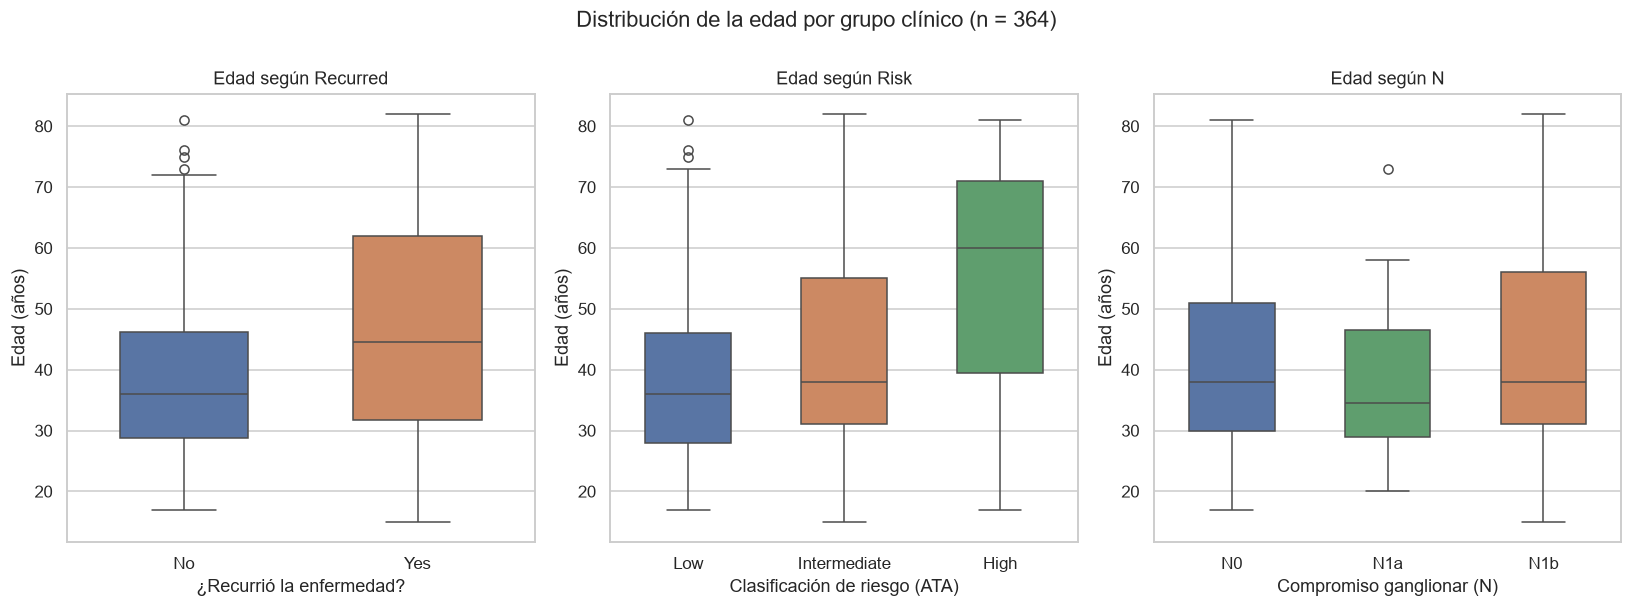

In [30]:
for col, orden in [("Recurred", ["No", "Yes"]),
                   ("Risk", ["Low", "Intermediate", "High"]),
                   ("N", ["N0", "N1a", "N1b"])]:
    print(f"--- Edad (años) por {col} ---")
    display(
        df.groupby(col, observed=True)["Age"]
          .agg(n="size", mediana="median", q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75), desv="std")
          .reindex(orden).round(2)
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
config = [
    ("Recurred", ["No", "Yes"], "¿Recurrió la enfermedad?"),
    ("Risk", ["Low", "Intermediate", "High"], "Clasificación de riesgo (ATA)"),
    ("N", ["N0", "N1a", "N1b"], "Compromiso ganglionar (N)"),
]
for ax, (col, orden, etiqueta_x) in zip(axes, config):
    sns.boxplot(
        data=df, x=col, y="Age", order=orden,
        hue=col, palette="deep", legend=False, width=0.55, ax=ax,
    )
    ax.set_title(f"Edad según {col}")
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel("Edad (años)")

fig.suptitle("Distribución de la edad por grupo clínico (n = 364)", y=1.0)
plt.tight_layout()
plt.show()


**Interpretación.** El primer panel cuantifica el desplazamiento ya visto en los histogramas: la mediana de edad es de 36 años en quienes no recurren y de 44,5 en quienes sí, y la caja del grupo con recurrencia es visiblemente más alta y **mucho más larga**, reflejo de su mayor dispersión (desviación estándar 18,27 frente a 13,16). Pese a ello, las dos cajas se solapan en un tramo amplio: la diferencia de medianas es real, pero no permite trazar una frontera entre los grupos, exactamente la misma conclusión del apartado 8.6 por otra vía.

El segundo panel es el más informativo de los tres. La mediana de edad sube de 36 años en riesgo bajo a 38 en riesgo intermedio y salta a **60 años en riesgo alto**, con una caja que apenas se solapa con la de los otros dos grupos. La categoría de riesgo alto no solo tiene el peor pronóstico, sino que además corresponde a pacientes claramente mayores.

El tercer panel, en cambio, resulta llamativamente plano: las medianas por compromiso ganglionar son 38, 34,5 y 38 años para N0, N1a y N1b respectivamente, es decir, prácticamente indistinguibles. Esto tiene una lectura clínica valiosa: **el compromiso ganglionar no es un fenómeno de la edad**, ocurre en pacientes jóvenes con la misma frecuencia que en mayores. Y sin embargo, como se vio en 8.2, la categoría N1b tiene una tasa de recurrencia del 76,3 %. Dicho de otro modo, `N` y `Age` aportan información **independiente y complementaria** sobre el riesgo. La complementariedad se comprueba con números: dentro de los pacientes N0, la tasa de recurrencia es del 5,2 % en los pacientes de hasta 40 años y del 36,2 % en los mayores de 55 años, de modo que la edad sigue discriminando incluso cuando el cuello es negativo. Son por tanto dos variables especialmente valiosas juntas dentro de un modelo, y no redundantes entre sí.

**Conexión con la decisión del Punto 7.** Los boxplots confirman gráficamente lo que allí se decidió sobre valores extremos. En la distribución global de `Age` las cercas del criterio de 1,5 · RIC caen en −3 y 85 años, un intervalo que **contiene a los 364 pacientes**: no hay ni un solo valor atípico por este criterio, coherente con un rango observado de 15 a 82 años. Los pocos puntos que el gráfico marca como atípicos aparecen únicamente **dentro de subgrupos** —por ejemplo pacientes mayores dentro del grupo sin recurrencia—, y eso no los convierte en errores: son atípicos respecto de su grupo, no del rango biológicamente plausible. Se ratifica por tanto la decisión de **no eliminar ninguna observación por edad**, tanto porque el criterio estadístico no identifica ninguna como porque todas las edades registradas son clínicamente verosímiles, y porque eliminar a los pacientes mayores sesgaría el modelo justo en la franja donde se concentran las recurrencias.

**Recomendación.** Se recomienda **mantener las 364 observaciones sin recorte por edad** y documentar esta decisión de forma explícita en el informe, señalando que se sustenta en el criterio del rango intercuartílico y en la plausibilidad clínica de todos los valores, y no en una omisión del análisis. En el plano asistencial, se recomienda **reforzar el seguimiento de los pacientes con riesgo alto, cuyo perfil combina edad avanzada y peor pronóstico, y mantener vigilancia sobre el compromiso ganglionar con independencia de la edad del paciente**: el tercer panel muestra que un cuello N1b en un paciente de 30 años tiene el mismo peso pronóstico que en uno de 60, y sería un error clínico relajar la vigilancia por juventud.


### 8.9 — Gráfica complementaria: mapa de calor de `Risk` frente a `Response`

Como cierre se cruzan las dos variables que en 8.2 mostraron mayor capacidad discriminante. Cada celda se colorea según la tasa de recurrencia del subgrupo y se anota con el porcentaje y el número de pacientes sobre el que se calcula, para que el tamaño muestral sea visible en la propia figura y no haya que buscarlo aparte.


Response,Excellent,Indeterminate,Biochemical Incomplete,Structural Incomplete
Risk,,,,
Low,171,36,13,10
Intermediate,18,25,7,52
High,0,0,3,29


Response,Excellent,Indeterminate,Biochemical Incomplete,Structural Incomplete
Risk,,,,
Low,0.0,2.8,15.4,90.0
Intermediate,5.6,24.0,85.7,98.1
High,NaN,NaN,100.0,100.0


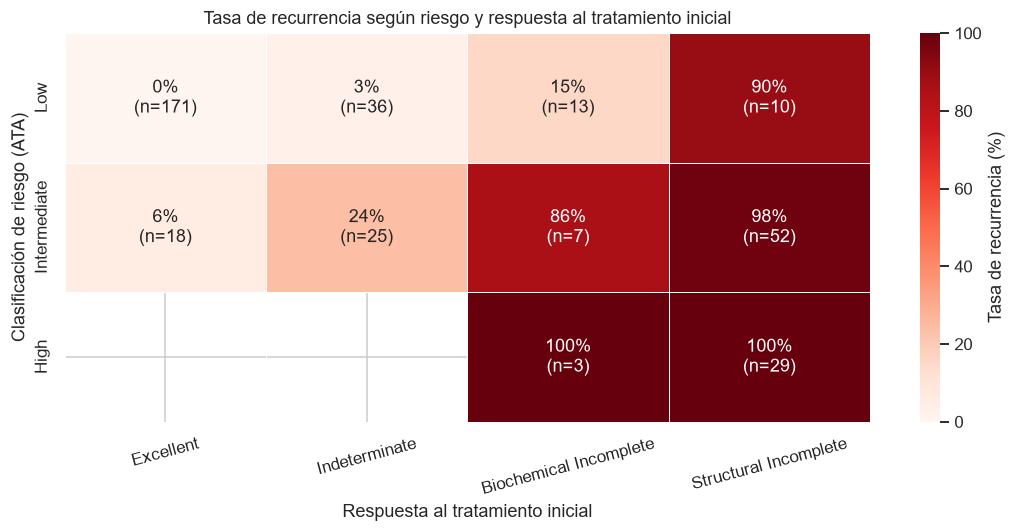

In [31]:
orden_risk = ["Low", "Intermediate", "High"]
orden_resp = ["Excellent", "Indeterminate", "Biochemical Incomplete", "Structural Incomplete"]

n_cruce = pd.crosstab(df["Risk"], df["Response"]).reindex(index=orden_risk, columns=orden_resp)
tasa_cruce = (
    pd.crosstab(df["Risk"], df["Response"], values=df["Recurred"].eq("Yes"), aggfunc="mean")
      .reindex(index=orden_risk, columns=orden_resp) * 100
)
display(n_cruce)
display(tasa_cruce.round(1))

etiquetas = tasa_cruce.map(lambda v: "" if pd.isna(v) else f"{v:.0f}%") + \
            n_cruce.map(lambda v: "" if pd.isna(v) or v == 0 else f"\n(n={int(v)})")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    tasa_cruce, annot=etiquetas.values, fmt="", cmap="Reds",
    vmin=0, vmax=100, linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Tasa de recurrencia (%)"}, ax=ax,
)
ax.set_title("Tasa de recurrencia según riesgo y respuesta al tratamiento inicial")
ax.set_xlabel("Respuesta al tratamiento inicial")
ax.set_ylabel("Clasificación de riesgo (ATA)")
ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout()
plt.show()


**Interpretación.** El mapa de calor ordena la cohorte en un gradiente diagonal muy limpio: la esquina superior izquierda (riesgo bajo con respuesta excelente) es prácticamente blanca, con tasas cercanas a cero, y la intensidad crece de forma sostenida hacia la esquina inferior derecha (riesgo alto con respuesta estructural incompleta), donde la recurrencia es total. El bloque de riesgo bajo con respuesta excelente reúne un número grande de pacientes con recurrencia casi nula, lo que lo convierte en el subgrupo de menor riesgo identificable de toda la cohorte y en el candidato natural a un seguimiento aligerado.

La lectura por filas y columnas muestra algo relevante para el modelado: **`Response` domina el resultado incluso dentro de un mismo nivel de riesgo**. Un paciente clasificado como riesgo bajo pero con respuesta estructural incompleta presenta una tasa de recurrencia muy alta, muy por encima de la de su fila; a la inversa, dentro del riesgo intermedio la respuesta excelente rebaja el riesgo de forma drástica. La respuesta al tratamiento, medida después de la cirugía, corrige la estimación pronóstica hecha en el momento del diagnóstico, que es exactamente para lo que fue diseñada la estratificación dinámica de la ATA.

Se repite aquí la advertencia estadística que atraviesa todo el punto, porque en un cruce de dos variables se agrava: al partir 364 pacientes en doce celdas, varias quedan con muy pocos casos —hay celdas con 3 y con 7 pacientes— y sus porcentajes, aunque estén pintados con el mismo color intenso que las celdas grandes, **no tienen la misma solidez**. El color de un mapa de calor no distingue una tasa calculada sobre los 171 pacientes de la celda más poblada (riesgo bajo con respuesta excelente) de una calculada sobre 3, y esa es precisamente la razón por la que se anotó el `n` dentro de cada celda.

**Recomendación.** Se recomienda **utilizar la combinación de `Risk` y `Response` como base del protocolo de seguimiento diferenciado**: seguimiento aligerado para el bloque de riesgo bajo con respuesta excelente, seguimiento estándar para las celdas intermedias y vigilancia intensiva para toda celda con respuesta estructural incompleta, con independencia del riesgo asignado al diagnóstico. Se recomienda igualmente **no tomar ninguna decisión de protocolo sobre una celda con menos de diez pacientes** sin validarla con una cohorte externa. Y en el plano del modelado, este cruce refuerza la recomendación del apartado 8.2: dado que `Response` arrastra tanto el resultado y se mide después del tratamiento, **su uso debe restringirse al modelo de seguimiento y excluirse del modelo pronóstico al diagnóstico**, para que la capacidad predictiva reportada sea honesta y no un reflejo de información que en la práctica todavía no está disponible.


## Punto 9 — Codificación de las variables categóricas

La codificación no se puede decidir en bloque, aplicando la misma técnica a todas las columnas "porque son categóricas". Cada variable tiene una naturaleza distinta —unas describen localización anatómica, otras severidad clínica creciente, otras un simple sí/no— y esa naturaleza es exactamente lo que determina qué técnica preserva la información y cuál la distorsiona. Por eso la decisión se toma variable por variable y se justifica caso a caso.

El problema de fondo del Ordinal Encoding aplicado sobre una variable sin orden es que **inyecta una distancia falsa**. Si a `Adenopathy` le asigno `Bilateral=0`, `Extensive=1`, `Left=2`, `No=3`, `Posterior=4`, `Right=5`, estoy afirmando implícitamente que un paciente con adenopatía izquierda está "más cerca" de uno con adenopatía bilateral (distancia 2) que de uno con adenopatía derecha (distancia 3). Clínicamente eso no significa absolutamente nada: son ubicaciones, no grados. El número no describe una magnitud, es solo una etiqueta que quedó ordenada alfabéticamente por accidente.

Ahora bien, ese defecto **no afecta a todos los modelos por igual**, y esa es la clave de la decisión:

- Los **árboles** (Decision Tree, Random Forest, Gradient Boosting) solo comparan cada feature contra un umbral: preguntan `Adenopathy <= 2.5`, nunca calculan distancias entre pacientes. Un orden arbitrario les cuesta, a lo sumo, necesitar varios splits sucesivos para aislar una categoría que un One-Hot habría aislado en uno solo. Con suficiente profundidad pueden recuperar cualquier partición del conjunto de categorías, así que el orden falso les resulta prácticamente inofensivo.
- **KNN** es el caso opuesto. Su métrica de distancia toma esos números al pie de la letra: la diferencia `|2 - 5| = 3` entra directamente en el cálculo euclidiano y define quiénes son los vecinos más cercanos. Un orden arbitrario aquí no es una ineficiencia, es una **deformación del espacio** que altera las predicciones.

Como en la Fase 4 los cuatro modelos —KNN, Decision Tree, Random Forest y Gradient Boosting— comparten un mismo `ColumnTransformer`, la codificación tiene que servirle al más exigente. La regla que sigo es simple: **codificar pensando en KNN**, porque lo que es correcto para KNN es a lo sumo neutro para los árboles, mientras que lo contrario no se cumple.

Hay además una particularidad de este dataset que eleva la importancia de este punto: **16 de las 17 variables son categóricas** y la única numérica es `Age`. Es decir, la codificación no es un paso menor de limpieza previa, es **la decisión que define casi por completo el espacio de features** sobre el que van a trabajar los cuatro modelos. Prácticamente toda la geometría del problema sale de aquí.


In [32]:
# Evidencia para sustentar la decisión: cardinalidad y distribución de cada variable categórica
cols_categoricas = [c for c in df.columns if c != "Age"]

filas = []
for col in cols_categoricas:
    vc = df[col].value_counts()
    filas.append({
        "Variable": col,
        "Cardinalidad": int(vc.size),
        "Categorías (ordenadas por frecuencia)": "  |  ".join(f"{k} ({v})" for k, v in vc.items()),
        "Menos frecuente": f"{vc.index[-1]} ({int(vc.iloc[-1])})",
    })

tabla_categoricas = pd.DataFrame(filas)
display(tabla_categoricas)

print(f"Variables categóricas: {len(cols_categoricas)} de {df.shape[1]} columnas totales")
print(f"Variables numéricas   : {df.shape[1] - len(cols_categoricas)} (solo 'Age')")
print(f"Cardinalidad máxima observada: {tabla_categoricas['Cardinalidad'].max()} "
      f"(ninguna variable es de alta cardinalidad)")


,Variable,Cardinalidad,Categorías (ordenadas por frecuencia),Menos frecuente
0,Gender,2,F (293) | M (71),M (71)
1,Smoking,2,No (315) | Yes (49),Yes (49)
2,Hx Smoking,2,No (336) | Yes (28),Yes (28)
3,Hx Radiotherapy,2,No (357) | Yes (7),Yes (7)
4,Thyroid Function,5,Euthyroid (313) | Clinical Hyperthyroidism (...,Subclinical Hyperthyroidism (5)
5,Physical Examination,5,Multinodular goiter (135) | Single nodular g...,Diffuse goiter (7)
6,Adenopathy,6,No (258) | Right (48) | Bilateral (32) | ...,Posterior (2)
7,Pathology,4,Papillary (271) | Micropapillary (45) | Fo...,Hurthle cell (20)
8,Focality,2,Uni-Focal (228) | Multi-Focal (136),Multi-Focal (136)
9,Risk,3,Low (230) | Intermediate (102) | High (32),High (32)


Variables categóricas: 16 de 17 columnas totales
Variables numéricas   : 1 (solo 'Age')
Cardinalidad máxima observada: 7 (ninguna variable es de alta cardinalidad)


### Tabla de decisión

| Variable | Cardinalidad | ¿Orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| `Gender` | 2 (F, M) | No | Binaria: One-Hot con `drop="first"` | Con dos categorías solo existe una distancia posible, así que no hay orden falso que introducir. |
| `Smoking` | 2 (No, Yes) | No | Binaria: One-Hot con `drop="first"` | Sí/no, se representa en una sola columna 0/1 sin pérdida de información. |
| `Hx Smoking` | 2 (No, Yes) | No | Binaria: One-Hot con `drop="first"` | Igual que la anterior; el 0/1 es la representación completa. |
| `Hx Radiotherapy` | 2 (No, Yes) | No | Binaria: One-Hot con `drop="first"` | Muy desbalanceada (solo 7 casos `Yes`), pero la codificación no cambia por eso. |
| `Focality` | 2 (Uni-Focal, Multi-Focal) | No | Binaria: One-Hot con `drop="first"` | Dos niveles; podría argumentarse que multifocal es "peor", pero con dos categorías el orden es irrelevante para la codificación. |
| `Thyroid Function` | 5 | No (ver nota) | One-Hot | Cardinalidad baja; el orden aparente no es lineal. |
| `Physical Examination` | 5 | No | One-Hot | Describe forma y lateralidad del bocio, no intensidad. |
| `Adenopathy` | 6 | No | One-Hot | Describe localización anatómica de los ganglios afectados. |
| `Pathology` | 4 | No | One-Hot | Tipos histológicos distintos, sin jerarquía numérica. |
| `Risk` | 3 | **Sí**: Low < Intermediate < High | Ordinal | Escala de riesgo clínico explícita; la tasa de recurrencia crece de forma monótona (5,2% → 62,7% → 100,0%). |
| `T` | 7 | **Sí**: T1a < T1b < T2 < T3a < T3b < T4a < T4b | Ordinal | Componente T del sistema TNM: tamaño y extensión local del tumor, definida como escala de severidad creciente. |
| `N` | 3 | **Sí**: N0 < N1a < N1b | Ordinal | Compromiso ganglionar creciente; recurrencia monótona (10,8% → 45,5% → 76,3%). |
| `M` | 2 | **Sí**: M0 < M1 | Ordinal | Ausencia/presencia de metástasis a distancia: binaria y ordinal a la vez, el 0/1 coincide con el orden real. |
| `Stage` | 5 | **Sí**: I < II < III < IVA < IVB | Ordinal | Estadificación TNM, escala de severidad global definida por consenso clínico. |
| `Response` | 4 | **Sí**: Excellent < Indeterminate < Biochemical Incomplete < Structural Incomplete | Ordinal | Severidad creciente de la respuesta al tratamiento; recurrencia monótona (0,5% → 11,5% → 47,8% → 97,8%). |

**Sobre las cinco binarias.** Con exactamente dos categorías, `OneHotEncoder(drop="first")` y `OrdinalEncoder` producen literalmente la misma columna 0/1: no hay diferencia de resultado, solo de nombre. Uso One-Hot con `drop="first"` por consistencia con el resto del pipeline y para que el nombre de la columna resultante deje explícita cuál es la categoría representada por el 1. Aquí no cabe el argumento del orden falso, porque con dos niveles solo hay una distancia posible entre ellos.

**Sobre las cuatro nominales.** Las cuatro tienen cardinalidad baja (entre 4 y 6), así que One-Hot agrega pocas columnas y no genera un problema de dimensionalidad:

- `Adenopathy` es el caso más claro. Sus categorías —`Right`, `Left`, `Bilateral`, `Posterior`, `Extensive`, `No`— describen **localización anatómica**, no intensidad. Numerarlas de 0 a 5 le diría a KNN que "posterior" está a distancia 3 de "izquierda" y a distancia 1 de "no hay adenopatía", afirmaciones que no tienen ningún significado clínico. One-Hot deja a todas las categorías a la misma distancia entre sí (√2), que es exactamente lo que quiero afirmar: son distintas, y ninguna está "entre" otras dos.
- `Thyroid Function` merece un matiz. Podría argumentarse que hay un orden, del tipo hipotiroidismo ← eutiroidismo → hipertiroidismo. Pero eso **no es un orden lineal, es una desviación en dos direcciones opuestas desde un centro**: el eutiroideo (funcionamiento normal) está en el medio, y los extremos se alejan hacia lados contrarios. Una sola columna ordinal no puede representar esa estructura sin mentir sobre alguna de las dos direcciones. One-Hot es la opción correcta.
- `Physical Examination` tiene un caso análogo: `Single nodular goiter-right` y `Single nodular goiter-left` son exactamente la misma severidad en lados distintos. Cualquier codificación ordinal las separaría artificialmente.
- `Pathology` son cuatro tipos histológicos (papilar, micropapilar, folicular, células de Hürthle). Aunque el pronóstico difiere entre ellos, no forman una escala que se pueda ordenar sin discusión, así que la codificación no debe imponer una.

**Sobre las seis ordinales.** Además del fundamento clínico y de la monotonía verificada en la tasa de recurrencia, hay un argumento de peso ligado al tamaño del dataset: aplicar One-Hot a estas seis variables agregaría **24 columnas** en lugar de 6, en un dataset de solo **364 pacientes** donde varias categorías tienen entre 2 y 8 registros (`Stage IVA` con 3, `Stage III` con 4, `T4b` con 8). Cada columna binaria adicional con 3 unos entre 364 filas aporta muy poca señal y sí ruido. Codificarlas como ordinales:

1. conserva la información de severidad, que es real y está respaldada por la evidencia, en una sola columna;
2. reduce la dimensionalidad, algo importante con tan pocos pacientes;
3. les permite a los árboles hacer cortes del tipo `T >= T3a` en **un solo split**, en vez de tener que combinar varias variables binarias en ramas sucesivas para expresar la misma condición.

Hay que reconocer, eso sí, la contrapartida, y es más seria de lo que suele admitirse cuando el modelo es KNN. El Ordinal Encoding no solo impone un orden: al codificar los niveles como 0, 1, 2, … impone también **equidistancia entre niveles consecutivos**, es decir, afirma que el salto de `T1a` a `T1b` mide exactamente lo mismo que el de `T3b` a `T4a` —ambos valen 1—, cuando clínicamente el segundo es mucho más grave. La distancia euclidiana toma ese supuesto al pie de la letra y construye el vecindario con él. Es una limitación que aquí se asume a conciencia: corregirla exigiría volver al One-Hot y a las 24 columnas que se acaban de descartar, un precio que con 364 pacientes no compensa.

Con ese supuesto declarado, cuando la variable sí tiene orden el Ordinal Encoding sigue siendo la codificación que más información transmite por columna.

**Sobre `Response` y el marco temporal.** Retomando la nota del Punto 1: `Response` es una variable **post-tratamiento**, no está disponible en el momento del diagnóstico. Al incluirla se adopta un marco temporal explícito: el modelo es una **herramienta de apoyo a la decisión de seguimiento después del tratamiento inicial**, cuando la respuesta ya fue observada y lo que se quiere estimar es el riesgo de recurrencia futura. Bajo ese marco es legítimo usarla. Si en cambio el objetivo fuera predecir en el momento del diagnóstico, `Response` tendría que excluirse, porque su relación con el desenlace es casi determinista (`Structural Incomplete` → 97,8% de recurrencia, `Excellent` → 0,5%) y el modelo se apoyaría casi exclusivamente en ella, aprendiendo poco del resto de variables. En la Fase 5 conviene revisar la importancia de features precisamente para verificar si eso está ocurriendo: si `Response` concentra casi toda la importancia, el modelo estará confirmando lo que un clínico ya sabe en vez de aportar información nueva.

**Sobre categorías no vistas.** Como hay categorías con 2 a 4 registros (`Adenopathy = Posterior` con 2, `Stage IVA` con 3, `Stage III` con 4), la partición train/validación/test puede dejar alguna de ellas completamente ausente del conjunto de entrenamiento. Si eso pasa, el encoder ajustado sobre train no la conoce y el `.transform()` sobre validación o test lanzaría una excepción, deteniendo el pipeline. Por eso los encoders se configuran así:

- `OneHotEncoder(handle_unknown="ignore")`: una categoría no vista se representa con **ceros en todas las columnas** de esa variable, en vez de fallar. Conviene precisar qué significa ese vector de ceros, porque **no significa lo mismo en los dos bloques**. En las cuatro nominales, que se codifican sin `drop`, cada categoría conocida tiene columna propia, así que el vector de ceros no coincide con ninguna de ellas y sí constituye un estado distinguible: "ninguna de las conocidas", una degradación razonable. En las cinco binarias, en cambio, se usa `drop="first"`, y ahí el vector de ceros **ya representa a la categoría eliminada** (`No`, `F`, la que quede como referencia): una etiqueta desconocida quedaría indistinguible de esa categoría de referencia, no marcada como desconocida. El riesgo es menor —con solo dos niveles y cientos de registros es muy improbable que uno falte en entrenamiento—, pero no hay que leer el vector de ceros como si siempre quisiera decir "ninguna".
- `OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)`: una categoría no vista recibe el valor **-1**, fuera del rango de las categorías conocidas. No es perfecto (queda "antes" de la primera categoría del orden), pero evita el error y afecta a poquísimas filas.

Sin estos parámetros, el pipeline sería frágil frente a una partición desafortunada, cosa perfectamente posible con 364 filas.

**Sobre el target.** `Recurred` se mapea a 0/1 con **`Yes` = 1**, y esta transformación se hace **fuera del `ColumnTransformer`**, porque el target nunca pasa por el preprocesamiento de features: el `ColumnTransformer` se ajusta sobre `X`, no sobre `y`. La elección de `Yes` como clase positiva no es arbitraria: la clase positiva debe ser el evento que se quiere detectar, y aquí ese evento es la recurrencia. De esa definición dependen directamente las métricas de la Fase 5 —precision, recall y F1 se calculan respecto a la clase positiva—, y como el costo de un falso negativo (un paciente que recurre y no se detecta) es clínicamente mucho mayor que el de un falso positivo, el recall sobre `Yes` es la métrica que más va a interesar.


In [33]:
# Especificación de preprocesamiento que consumirá el ColumnTransformer de la Fase 2
COLS_NUM = ["Age"]
COLS_BINARIAS = ["Gender", "Smoking", "Hx Smoking", "Hx Radiotherapy", "Focality"]
COLS_ONEHOT = ["Thyroid Function", "Physical Examination", "Adenopathy", "Pathology"]
COLS_ORDINAL = ["Risk", "T", "N", "M", "Stage", "Response"]
ORDENES_ORDINAL = [
    ["Low", "Intermediate", "High"],
    ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"],
    ["N0", "N1a", "N1b"],
    ["M0", "M1"],
    ["I", "II", "III", "IVA", "IVB"],
    ["Excellent", "Indeterminate", "Biochemical Incomplete", "Structural Incomplete"],
]
TARGET = "Recurred"

# --- Verificación (a): cada columna de df queda asignada a exactamente una lista ---
asignadas = COLS_NUM + COLS_BINARIAS + COLS_ONEHOT + COLS_ORDINAL + [TARGET]
sin_asignar = [c for c in df.columns if c not in asignadas]
inexistentes = [c for c in asignadas if c not in df.columns]
repetidas = sorted({c for c in asignadas if asignadas.count(c) > 1})

print("VERIFICACIÓN (a) — cobertura de columnas")
print(f"  columnas en df           : {df.shape[1]}")
print(f"  columnas asignadas       : {len(asignadas)}")
print(f"  sin asignar              : {sin_asignar if sin_asignar else 'ninguna'}")
print(f"  asignadas pero inexistentes: {inexistentes if inexistentes else 'ninguna'}")
print(f"  repetidas en varias listas : {repetidas if repetidas else 'ninguna'}")
ok_a = not (sin_asignar or inexistentes or repetidas)
print(f"  RESULTADO: {'OK — todas las columnas cubiertas, sin olvidos ni repeticiones' if ok_a else 'FALLA'}")

# --- Verificación (b): cada orden declarado coincide con las categorías reales de su columna ---
print("\nVERIFICACIÓN (b) — correspondencia de los órdenes ordinales")
filas_ord = []
ok_b = True
for col, orden in zip(COLS_ORDINAL, ORDENES_ORDINAL):
    reales = set(df[col].unique())
    declaradas = set(orden)
    faltan = sorted(reales - declaradas)     # están en los datos, no en el orden -> rompe el fit
    sobran = sorted(declaradas - reales)     # están en el orden, no en los datos
    coincide = not faltan and not sobran
    ok_b = ok_b and coincide
    filas_ord.append({
        "Variable": col,
        "Categorías en datos": len(reales),
        "Categorías declaradas": len(orden),
        "Faltan en el orden": ", ".join(faltan) if faltan else "-",
        "Sobran en el orden": ", ".join(sobran) if sobran else "-",
        "¿Coincide?": "OK" if coincide else "FALLA",
    })
display(pd.DataFrame(filas_ord))
print(f"  RESULTADO: {'OK — todos los órdenes son válidos para el OrdinalEncoder' if ok_b else 'FALLA'}")

# --- Dimensionalidad del esquema resultante ---
n_num = len(COLS_NUM)
n_bin = len(COLS_BINARIAS)                                     # drop="first" -> 1 columna por variable
n_ohe = sum(df[c].nunique() for c in COLS_ONEHOT)
n_ord = len(COLS_ORDINAL)                                      # 1 columna por variable
total_cols = n_num + n_bin + n_ohe + n_ord
ohe_si_ordinales = sum(df[c].nunique() for c in COLS_ORDINAL)

print("\nDIMENSIONALIDAD DEL ESQUEMA")
print(f"  numérica (Age)                      : {n_num}")
print(f"  binarias (One-Hot drop='first')     : {n_bin}")
print(f"  nominales One-Hot                   : {n_ohe}")
print(f"  ordinales                           : {n_ord}")
print(f"  TOTAL columnas de features          : {total_cols}")
print(f"\n  Si las 6 ordinales se codificaran One-Hot: {ohe_si_ordinales} columnas en vez de {n_ord} "
      f"(total subiría a {total_cols - n_ord + ohe_si_ordinales}) sobre solo {len(df)} pacientes.")


VERIFICACIÓN (a) — cobertura de columnas
  columnas en df           : 17
  columnas asignadas       : 17
  sin asignar              : ninguna
  asignadas pero inexistentes: ninguna
  repetidas en varias listas : ninguna
  RESULTADO: OK — todas las columnas cubiertas, sin olvidos ni repeticiones

VERIFICACIÓN (b) — correspondencia de los órdenes ordinales


,Variable,Categorías en datos,Categorías declaradas,Faltan en el orden,Sobran en el orden,¿Coincide?
0,Risk,3,3,-,-,OK
1,T,7,7,-,-,OK
2,N,3,3,-,-,OK
3,M,2,2,-,-,OK
4,Stage,5,5,-,-,OK
5,Response,4,4,-,-,OK


  RESULTADO: OK — todos los órdenes son válidos para el OrdinalEncoder

DIMENSIONALIDAD DEL ESQUEMA
  numérica (Age)                      : 1
  binarias (One-Hot drop='first')     : 5
  nominales One-Hot                   : 20
  ordinales                           : 6
  TOTAL columnas de features          : 32

  Si las 6 ordinales se codificaran One-Hot: 24 columnas en vez de 6 (total subiría a 50) sobre solo 364 pacientes.


## Punto 10 — Escalamiento de las variables numéricas

### Decisión: sí se escala, y la razón se llama KNN

Después de la codificación del Punto 9, el espacio de features queda muy desigual en escalas. `Age` recorre de 15 a 82 —un rango de 67 unidades—, mientras que **todas las demás columnas quedan en 0/1** (las One-Hot y las binarias) o en **enteros pequeños de 0 a 6** (las ordinales). Sin escalar, la distancia euclidiana que usa KNN queda dominada casi por completo por la diferencia de edad. Vale la pena hacer el cálculo explícito:

- dos pacientes que difieren 30 años aportan **30** a la distancia (900 en la distancia al cuadrado);
- dos pacientes en estadios opuestos, `I` frente a `IVB`, aportan **4** (16 en la distancia al cuadrado);
- dos pacientes con patologías distintas, bajo One-Hot, aportan **√2 ≈ 1,41** (2 en la distancia al cuadrado);
- dos pacientes que difieren en el género aportan **1**.

Es decir, una diferencia de 30 años pesa **450 veces más** que una diferencia de patología, y unas **56 veces más** que la diferencia entre el estadio más leve y el más grave. Los vecinos "más cercanos" que encontraría KNN serían, en la práctica, los pacientes de edad parecida, casi sin importar su estadio, su respuesta al tratamiento o su compromiso ganglionar. **El modelo se convertiría en un clasificador por edad disfrazado de KNN.** Este es el argumento central del punto: escalar no es un trámite, es lo que permite que las **31 columnas restantes** —las que generan las 15 variables clínicas categóricas al codificarlas— participen realmente de la decisión.

Para **Decision Tree, Random Forest y Gradient Boosting** el escalamiento es **irrelevante**. Estos modelos son invariantes a cualquier transformación monótona aplicada a cada variable por separado, porque solo comparan cada feature contra un umbral: un split en `Age <= 45` sobre los datos originales es exactamente el mismo split que `Age_escalada <= 0.24` sobre los datos estandarizados, con la misma partición de las filas y la misma ganancia de información. Lo importante es que aplicarlo **no los perjudica**: no degrada su desempeño ni distorsiona nada. Gracias a eso es viable mantener **un único pipeline de preprocesamiento compartido** por los cuatro modelos, en vez de dos rutas distintas que habría que sincronizar a mano y que multiplicarían las posibilidades de error al comparar resultados.

### Qué se escala y con qué técnica

**`Age` → `StandardScaler`.** Del Punto 7 se tiene la evidencia relevante: **0 outliers por el criterio IQR**, asimetría moderada (skew = 0,678), y un rango acotado y clínicamente plausible (15 a 82 años, sin edades imposibles ni códigos de error). Al no haber valores extremos, el argumento habitual a favor de `RobustScaler` —que usa mediana e IQR justamente para no dejarse arrastrar por outliers— pierde su motivación: **con datos sin valores extremos, `StandardScaler` y `RobustScaler` producen resultados muy similares**, como se comprueba abajo comparando los percentiles resultantes de cada uno.

Elijo `StandardScaler` por dos razones concretas: no hay outliers que puedan distorsionar la media ni la desviación estándar (que es exactamente el escenario donde este escalador funciona bien), y deja la variable **centrada en 0 con desviación 1**, que es la escala que mejor se compara con las columnas binarias en 0/1 —una diferencia de una desviación estándar en edad pesa aproximadamente lo mismo que una diferencia de categoría en una variable binaria, que es un balance razonable para la distancia. Dicho con honestidad: **`RobustScaler` también sería perfectamente aceptable aquí y la diferencia práctica es pequeña**; no tendría sentido pretender que una opción es claramente superior cuando la evidencia muestra que ambas producen prácticamente lo mismo.

`MinMaxScaler` sí se descarta con un argumento concreto: ancla el 0 y el 1 en el **mínimo y máximo observados en train**. Un paciente de validación o test más joven que el mínimo de train o mayor que su máximo quedaría fuera del rango [0, 1], rompiendo la garantía que es la razón misma de usar este escalador. Con solo 364 pacientes y una única variable numérica, la probabilidad de que el rango de train no cubra el de test **no es despreciable**: basta con que el paciente de 82 años, o el de 15, caiga del lado de test.

**Las ordinales también se escalan.** Este es un detalle que se suele pasar por alto y que sí afecta el resultado. Después del `OrdinalEncoder`, `T` toma valores de 0 a 6 y `Stage` de 0 a 4, mientras que las binarias y las One-Hot están en 0/1. Sin escalar, `T` pesaría en la distancia euclidiana hasta **36 veces más** (6² frente a 1²) que cualquier variable binaria, no porque sea más importante clínicamente, sino simplemente porque tiene más categorías. Ese sesgo es arbitrario y hay que atenuarlo: las ordinales pasan por el mismo `StandardScaler` que `Age`. Ahora bien, conviene decir con precisión qué consigue ese escalado, porque **reduce el desbalance de pesos pero no lo elimina, y de hecho invierte su signo**. Tras estandarizar, cada ordinal queda con desviación 1, mientras que una columna One-Hot balanceada tiene una desviación de alrededor de 0,5 y una columna rara apenas 0,14 —y esas se dejan sin escalar—, de modo que las ordinales terminan pesando unas 4 veces más que una binaria equilibrada, en vez de las 36 de partida. La decisión sigue siendo defendible: acerca los órdenes de magnitud y deja con más peso justamente a las variables clínicamente más informativas del conjunto. Pero es un compromiso, no una neutralización, y presentarlo como si dejara a todas las features en igualdad de condiciones sería faltar a la verdad.

**Las One-Hot y las binarias no se escalan.** Ya están en 0/1, que es un rango homogéneo y comparable, y estandarizarlas solo cambiaría la interpretación sin ganar nada. Peor aún: con categorías muy raras, estandarizar es activamente contraproducente. Una columna con **7 unos entre 364 filas** (el caso de `Hx Radiotherapy = Yes`, o de `Physical Examination = Normal`) tiene media ≈ 0,019 y desviación ≈ 0,137; al estandarizarla, esos 7 casos pasan a valer alrededor de **7,2**, mientras el resto queda en −0,14. Esos siete pacientes quedarían a una distancia enorme de todos los demás en esa dimensión, y KNN los trataría como outliers extremos por el solo hecho de pertenecer a una categoría poco frecuente. Dejar las columnas binarias en 0/1 evita ese artefacto por completo.

### Regla de oro: el `fit` va solo sobre train

El escalador se ajusta (`.fit()`) **únicamente sobre `X_train`**; sobre validación y test se aplica solo `.transform()`, usando la media y la desviación aprendidas en train. La razón: si la media y la desviación se calcularan sobre todo el dataset, información de validación y test se filtraría al preprocesamiento (*data leakage*), el modelo estaría viendo indirectamente datos que se supone no conoce, y las métricas quedarían optimistas —es decir, mentirían sobre el desempeño real frente a pacientes nuevos. Encapsular escalador y modelo dentro de un `Pipeline` de scikit-learn garantiza esto de forma automática, incluso durante la validación cruzada, donde el error es más fácil de cometer sin darse cuenta.

### Sobre el desbalance del target (y por qué no se corrige aquí)

El target está desbalanceado: **70,33% `No` frente a 29,67% `Yes`**. Es un desbalance moderado, no extremo, pero suficiente para que un clasificador trivial que prediga siempre "no recurre" alcance un 70,33% de accuracy sin haber aprendido nada. Aun así, **el balanceo no se aborda en esta fase**, por dos razones:

1. Es una **decisión de modelado, no de preprocesamiento de features**. `class_weight="balanced"`, SMOTE o el submuestreo modifican cómo el modelo aprende o cómo se distribuyen las clases, no cómo se representan las variables. Su lugar natural es la Fase 4, junto con la elección de hiperparámetros.
2. Cualquier remuestreo debe hacerse **solo sobre train y dentro del pipeline**. Generar muestras sintéticas antes de partir el dataset contaminaría validación y test con información derivada de las filas de entrenamiento (e incluso con copias casi idénticas de ellas), inflando las métricas de forma artificial.

Lo que sí corresponde dejar anotado desde ya, retomando lo dicho en el Punto 1: la partición debe hacerse **estratificada por `Recurred`** —con solo 108 casos positivos, una partición aleatoria simple puede desbalancear los conjuntos de forma notoria— y la evaluación de la Fase 5 debe **priorizar recall y F1 sobre la clase positiva por encima del accuracy**, porque el costo de no detectar una recurrencia es clínicamente mucho mayor que el de una falsa alarma que se resuelve con seguimiento adicional.


In [34]:
# Estadísticos de 'Age' que sustentan la elección del escalador (recuperados del Punto 7)
q1, q3 = df["Age"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_outliers = int(((df["Age"] < lim_inf) | (df["Age"] > lim_sup)).sum())

resumen_age = pd.DataFrame([{
    "Variable": "Age",
    "Mín": int(df["Age"].min()),
    "Q1": float(q1),
    "Mediana": float(df["Age"].median()),
    "Q3": float(q3),
    "Máx": int(df["Age"].max()),
    "Media": round(float(df["Age"].mean()), 2),
    "Std": round(float(df["Age"].std()), 2),
    "IQR": float(iqr),
    "Límite inf. IQR": float(lim_inf),
    "Límite sup. IQR": float(lim_sup),
    "Outliers IQR": n_outliers,
    "Skew": round(float(df["Age"].skew()), 3),
}])
display(resumen_age)

print(f"Sin outliers por criterio IQR ({n_outliers} casos fuera de [{lim_inf:.1f}, {lim_sup:.1f}]),")
print("el argumento a favor de RobustScaler pierde fuerza: no hay valores extremos que distorsionen")
print(f"media y desviación. La asimetría es moderada (skew = {df['Age'].skew():.3f}).")


,Variable,Mín,Q1,Mediana,Q3,Máx,Media,Std,IQR,Límite inf. IQR,Límite sup. IQR,Outliers IQR,Skew
0,Age,15,30.0,38.0,52.0,82,41.25,15.31,22.0,-3.0,85.0,0,0.678


Sin outliers por criterio IQR (0 casos fuera de [-3.0, 85.0]),
el argumento a favor de RobustScaler pierde fuerza: no hay valores extremos que distorsionen
media y desviación. La asimetría es moderada (skew = 0.678).


In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Comparación demostrativa de los tres escaladores sobre 'Age'
edad = df[["Age"]]
comparacion = pd.DataFrame({"Original": df["Age"].astype(float)})
for nombre, escalador in [("StandardScaler", StandardScaler()),
                          ("MinMaxScaler", MinMaxScaler()),
                          ("RobustScaler", RobustScaler())]:
    comparacion[nombre] = escalador.fit_transform(edad).ravel()

tabla_escaladores = (comparacion
                     .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
                     .drop(index="count")
                     .round(3))
display(tabla_escaladores)

# Distancia entre el paciente más joven y el más viejo bajo cada escalador
print("Rango total (máx - mín) de 'Age' bajo cada escalador:")
for nombre in ["Original", "StandardScaler", "MinMaxScaler", "RobustScaler"]:
    col = comparacion[nombre]
    print(f"  {nombre:<15}: {col.max() - col.min():.3f}   "
          f"[mín = {col.min():.3f}, máx = {col.max():.3f}]")

# La evidencia válida es la tabla de percentiles de arriba: al no haber outliers, la media y la
# mediana de 'Age' casi coinciden y ambos escaladores dejan la variable en escalas muy parecidas.
# NO sirve para esto comparar la correlación entre las dos versiones escaladas: StandardScaler y
# RobustScaler son transformaciones AFINES de la misma columna, así que su correlación vale 1 por
# construcción, haya outliers o no, y no distingue un caso del otro.
print("\nAl no haber outliers, ambos escaladores son prácticamente equivalentes (compárense los")
print("percentiles de la tabla de arriba, que es la evidencia pertinente); se elige")
print("StandardScaler por dejar la variable centrada en 0 con desviación 1, escala comparable")
print("con las columnas binarias en 0/1. MinMaxScaler se descarta porque ancla el rango [0,1]")
print("en el mín y el máx de train, y un paciente fuera de ese rango en test quedaría por fuera.")
print("\nNOTA: este cálculo es DEMOSTRATIVO sobre el dataset completo, para comparar las tres")
print("técnicas con evidencia. El escalador definitivo se ajusta SOLO sobre X_train, dentro del")
print("pipeline de la Fase 2, para no filtrar información de validación ni de test.")


,Original,StandardScaler,MinMaxScaler,RobustScaler
mean,41.250,0.000,0.392,0.148
std,15.314,1.001,0.229,0.696
min,15.000,-1.716,0.000,-1.045
1%,17.630,-1.544,0.039,-0.926
5%,21.000,-1.324,0.090,-0.773
25%,30.000,-0.736,0.224,-0.364
50%,38.000,-0.213,0.343,0.000
75%,52.000,0.703,0.552,0.636
95%,70.850,1.935,0.834,1.493
99%,80.000,2.534,0.970,1.909


Rango total (máx - mín) de 'Age' bajo cada escalador:
  Original       : 67.000   [mín = 15.000, máx = 82.000]
  StandardScaler : 4.381   [mín = -1.716, máx = 2.665]
  MinMaxScaler   : 1.000   [mín = 0.000, máx = 1.000]
  RobustScaler   : 3.045   [mín = -1.045, máx = 2.000]

Al no haber outliers, ambos escaladores son prácticamente equivalentes (compárense los
percentiles de la tabla de arriba, que es la evidencia pertinente); se elige
StandardScaler por dejar la variable centrada en 0 con desviación 1, escala comparable
con las columnas binarias en 0/1. MinMaxScaler se descarta porque ancla el rango [0,1]
en el mín y el máx de train, y un paciente fuera de ese rango en test quedaría por fuera.

NOTA: este cálculo es DEMOSTRATIVO sobre el dataset completo, para comparar las tres
técnicas con evidencia. El escalador definitivo se ajusta SOLO sobre X_train, dentro del
pipeline de la Fase 2, para no filtrar información de validación ni de test.


### Especificación completa de preprocesamiento (resumen de los Puntos 4, 9 y 10)

| Bloque | Columnas | Imputador | Transformación |
|---|---|---|---|
| **Numérica** | `Age` | No requerido (0 nulos); `SimpleImputer(strategy="median")` como resguardo defensivo en el pipeline | `StandardScaler` |
| **Binarias** | `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiotherapy`, `Focality` | `SimpleImputer(strategy="most_frequent")` como resguardo | `OneHotEncoder(drop="first", handle_unknown="ignore")` → 1 columna 0/1 cada una, **sin escalar** |
| **Nominales (One-Hot)** | `Thyroid Function`, `Physical Examination`, `Adenopathy`, `Pathology` | `SimpleImputer(strategy="most_frequent")` como resguardo | `OneHotEncoder(handle_unknown="ignore")` → 20 columnas 0/1, **sin escalar** |
| **Ordinales** | `Risk`, `T`, `N`, `M`, `Stage`, `Response` | `SimpleImputer(strategy="most_frequent")` como resguardo | `OrdinalEncoder(categories=ORDENES_ORDINAL, handle_unknown="use_encoded_value", unknown_value=-1)` + `StandardScaler` |
| **Target** | `Recurred` | — | Mapeo `{"No": 0, "Yes": 1}` **fuera del `ColumnTransformer`**; `Yes` = clase positiva |

El esquema produce **32 columnas de features** a partir de las 16 variables predictoras originales, y el mismo `ColumnTransformer` alimenta a los cuatro modelos de la Fase 4 (KNN, Decision Tree, Random Forest y Gradient Boosting). Los imputadores se incluyen aunque el dataset no tenga valores nulos, no por necesidad actual sino como resguardo del pipeline: si en producción llegara un registro incompleto, el `transform` no fallaría.

**Sobre el marco temporal de este esquema.** La especificación de arriba corresponde al **escenario de seguimiento post-tratamiento**, que es el marco adoptado en el Punto 1, y por eso incluye `Response` entre las ordinales. El escenario alternativo —el modelo **pronóstico al diagnóstico** que se recomendó en los apartados 8.2 y 8.9— no necesita un esquema distinto: basta con retirar `Response` de `COLS_ORDINAL` y su orden correspondiente de `ORDENES_ORDINAL`, con lo que el bloque ordinal baja a cinco columnas y el total a 31 features, sin tocar nada más. Se recomienda que la Fase 2 construya los dos y que la Fase 5 los compare: la caída de desempeño entre uno y otro es exactamente la medida de cuánto del acierto proviene de una variable que en el momento del diagnóstico todavía no existe.

Dos decisiones quedan explícitamente fuera de esta fase y se retoman después: el manejo del desbalance de clases (Fase 4, solo sobre train) y la revisión de la importancia de features para evaluar el peso de `Response` en las predicciones (Fase 5).


---

## Cierre de la Fase 1 — resumen de decisiones

| Punto | Decisión tomada | Sustento |
|---|---|---|
| 4 | No hay nulos que imputar; se deja el imputador en el pipeline como defensa ante datos nuevos | Mediana para `Age`, moda para las categóricas; nunca imputar el target |
| 5 | Se eliminan 19 filas duplicadas exactas (383 → 364) | Todas pertenecían a la clase mayoritaria; conservarlas arriesgaba fuga entre train y validación |
| 6 | Se corrige `Hx Radiothreapy` → `Hx Radiotherapy` y `Hurthel cell` → `Hurthle cell` | Errores tipográficos del archivo original; el resto se conserva por trazabilidad |
| 7 | Los valores extremos de `Age` y las categorías raras se **documentan y se conservan** | Son casos clínicos reales; las categorías raras son justamente los casos de alto riesgo |
| 9 | One-Hot para las nominales, Ordinal para `Risk`, `T`, `N`, `M`, `Stage` y `Response` | Esas seis tienen orden clínico real y tasa de recurrencia monótona |
| 10 | Se escalan `Age` y las ordinales; las binarias y One-Hot no | KNN es el modelo sensible a distancia y `Age` dominaría por completo la métrica |

La especificación de preprocesamiento queda definida en las listas `COLS_NUM`, `COLS_BINARIAS`, `COLS_ONEHOT`, `COLS_ORDINAL` y `ORDENES_ORDINAL` del punto 9, que son las que consumirá el `ColumnTransformer` de la Fase 2.

Dos advertencias metodológicas que hay que arrastrar a las fases siguientes: la partición train/validation/test debe ser **estratificada por `Recurred`** para preservar la proporción 70/30 en los tres conjuntos, y la métrica principal de comparación debe ser el **recall** (o el F1) sobre la clase positiva, no la accuracy, porque un clasificador trivial que siempre respondiera "No recurre" ya alcanzaría un 70% de aciertos sin haber aprendido nada.


---

# Fase 2 — División de datos y Pipelines

La Fase 1 dejó escrita la especificación completa del preprocesamiento y dos advertencias que hay que arrastrar hasta aquí: la partición debe ser **estratificada por `Recurred`**, y la métrica de comparación no puede ser la accuracy. La primera se resuelve en este punto; la segunda queda anotada para la Fase 5.

## Punto 11 — División estratificada en train / validation / test

### Para qué sirve cada conjunto

- **Entrenamiento (70 %).** Lo único que el modelo ve mientras aprende. Aquí se ajustan los parámetros del algoritmo y también los de las transformaciones: la media y la desviación del `StandardScaler`, el vocabulario del `OneHotEncoder`, la moda de cada imputador.
- **Validación (15 %).** El conjunto sobre el que se comparan los modelos y se elige uno.
- **Test (15 %).** Intacto hasta la Fase 6, es la estimación final e imparcial del desempeño.

### Por qué no basta con train/test

Porque **el conjunto de validación se gasta al usarlo**. Al comparar varios modelos sobre las mismas filas y quedarse con el mejor, la elección ya incorporó información de esas filas: el ganador lo es en parte porque se acomoda a sus particularidades. Si esa comparación se hiciera sobre test, se perdería la única medición neutral disponible. Con tres conjuntos, cada uno responde una pregunta distinta —validación responde "¿cuál modelo elijo?", test responde "¿qué tan bueno es de verdad?"— y ninguno responde las dos.

### Por qué aquí la estratificación no es opcional

En el problema de vuelos la partición aleatoria bastaba porque había 300 mil filas y el objetivo era continuo. Aquí la situación es la contraria: **364 pacientes y un objetivo binario desbalanceado** (70,3 % sin recurrencia, 29,7 % con recurrencia). Sobre un conjunto de validación de unas 55 personas, un corte aleatorio sin estratificar puede dejar por azar una proporción de casos positivos bastante distinta de la real, y entonces las métricas de la clase positiva —que son las que importan en un problema de diagnóstico— medirían el corte antes que el modelo.

`stratify` reparte cada clase proporcionalmente entre los conjuntos y elimina esa fuente de ruido. Se aplica en los **dos** cortes: si solo se estratificara el primero, el reparto posterior entre validación y test volvería a ser aleatorio.

In [36]:
from sklearn.model_selection import train_test_split

SEMILLA = 42        # única fuente de aleatoriedad: partición y modelos la comparten.

# El target se mapea a 0/1 FUERA del ColumnTransformer, tal como se especificó en el Punto 9.
# 'Yes' = 1 es la clase positiva: el paciente cuya enfermedad recurrió. Esa convención importa,
# porque precision y recall en la Fase 5 se calculan respecto de la clase 1.
X = df.drop(columns=[TARGET])
y = df[TARGET].map({"No": 0, "Yes": 1})

assert y.notna().all(), "El mapeo dejó nulos: hay etiquetas de Recurred fuera de {No, Yes}"

X_train, X_resto, y_train, y_resto = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_resto, y_resto, test_size=0.50, random_state=SEMILLA, stratify=y_resto
)

print(f"Pacientes en la cohorte depurada: {len(X)}\n")
for nombre, subset in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {nombre:11s}: {len(subset):>4} pacientes  ({len(subset) / len(X):6.2%})")

Pacientes en la cohorte depurada: 364

  train      :  254 pacientes  (69.78%)
  validation :   55 pacientes  (15.11%)
  test       :   55 pacientes  (15.11%)


In [37]:
# Verificación de que la estratificación efectivamente preservó la proporción de clases.
filas = []
for nombre, sub_y in [("train", y_train), ("validation", y_val),
                      ("test", y_test), ("cohorte completa", y)]:
    filas.append({
        "conjunto": nombre,
        "n": len(sub_y),
        "recurrencias (Yes = 1)": int(sub_y.sum()),
        "sin recurrencia (No = 0)": int((sub_y == 0).sum()),
        "% clase positiva": round(100 * sub_y.mean(), 2),
    })
display(pd.DataFrame(filas).set_index("conjunto"))

# El tamaño del conjunto de validación condiciona lo fina que puede ser la lectura de la Fase 5.
positivos_val = int(y_val.sum())
print(f"Casos positivos en validación: {positivos_val}")
print(f"Un solo falso negativo mueve el recall {100 / positivos_val:.2f} puntos porcentuales.")

,n,recurrencias (Yes = 1),sin recurrencia (No = 0),% clase positiva
conjunto,,,,
train,254,75,179,29.53
validation,55,17,38,30.91
test,55,16,39,29.09
cohorte completa,364,108,256,29.67


Casos positivos en validación: 17
Un solo falso negativo mueve el recall 5.88 puntos porcentuales.


Los porcentajes de clase positiva de los tres conjuntos deben quedar prácticamente idénticos al de la cohorte completa; las diferencias que aparezcan son solo el redondeo inevitable de repartir un número entero de pacientes.

La última línea impresa es la que conviene tener presente durante toda la Fase 5. Con alrededor de **16 casos positivos en validación**, cada acierto o error individual mueve el recall más de seis puntos porcentuales. Esto no invalida la comparación entre modelos, pero sí obliga a leerla con prudencia: una diferencia de tres o cuatro puntos de recall entre dos modelos puede corresponder a un solo paciente clasificado distinto, y no es evidencia suficiente para declarar a uno superior al otro. Es exactamente el argumento que hace de la validación cruzada de la Fase 7 algo más que un requisito del enunciado: al promediar sobre varios cortes, reduce esta lotería.

## Punto 12 — Pipelines con ColumnTransformer

El preprocesamiento tiene aquí cuatro bloques en lugar de tres, porque el Punto 9 distinguió entre categóricas binarias y nominales de más de dos categorías. Cada bloque es un `Pipeline` interno —imputar primero, transformar después— y el `ColumnTransformer` reparte las columnas entre ellos.

Una diferencia importante frente al notebook de vuelos: aquí **las variables ordinales sí se escalan**. Después del `OrdinalEncoder`, la columna `T` recorre los enteros 0 a 6 mientras que una columna One-Hot solo toma los valores 0 o 1. Para KNN, que es el modelo que mide distancias, `T` pesaría siete veces más que cualquier variable binaria sin ninguna razón sustantiva. El `StandardScaler` posterior las deja a todas en una escala comparable.

### Los dos escenarios

La Fase 1 recomendó construir dos versiones del modelo y esta celda las produce con la misma función. La diferencia es una sola variable, `Response`, y el motivo es cronológico: `Response` registra **cómo respondió el paciente al tratamiento**, información que no existe todavía en el momento del diagnóstico.

- **Escenario de seguimiento** (con `Response`, 32 features): responde "dado todo lo que sé de este paciente, incluida su respuesta al tratamiento, ¿va a recurrir?". Es útil para priorizar controles post-tratamiento.
- **Escenario de diagnóstico** (sin `Response`, 31 features): responde "en el momento del diagnóstico, ¿qué riesgo de recurrencia tiene este paciente?". Es la pregunta clínicamente más ambiciosa y la única que se puede contestar el primer día.

Un modelo que use `Response` para responder la segunda pregunta estaría usando información del futuro. No es fuga de datos en el sentido técnico —`Response` es una columna legítima del dataset y se ajusta solo sobre train—, pero sí una fuga conceptual: el modelo parecería excelente en el papel y sería inaplicable en la consulta. La brecha de desempeño entre los dos escenarios, que medirá la Fase 5, es precisamente la medida de cuánto del acierto proviene de esa variable.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


def construir_preprocesador(incluir_response: bool = True) -> ColumnTransformer:
    """Devuelve el ColumnTransformer especificado en el Punto 10.

    incluir_response=True  -> escenario de seguimiento post-tratamiento
    incluir_response=False -> escenario pronóstico al diagnóstico

    Al retirar 'Response' hay que quitar SIMULTÁNEAMENTE la columna de COLS_ORDINAL y su orden
    de ORDENES_ORDINAL: las dos listas van emparejadas por posición, y desincronizarlas haría
    que el OrdinalEncoder aplicara a una variable el orden de otra.
    """
    if incluir_response:
        cols_ord, ordenes = list(COLS_ORDINAL), list(ORDENES_ORDINAL)
    else:
        pares = [(c, o) for c, o in zip(COLS_ORDINAL, ORDENES_ORDINAL) if c != "Response"]
        cols_ord = [c for c, _ in pares]
        ordenes = [o for _, o in pares]

    # Numérica: mediana como resguardo (no hay nulos) + StandardScaler (Puntos 4 y 10).
    bloque_num = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ])

    # Binarias: con dos categorías, la segunda columna One-Hot es redundante -> drop="first".
    bloque_bin = Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(drop="first", handle_unknown="ignore",
                                      sparse_output=False)),
    ])

    # Nominales sin orden natural: One-Hot completo, para no inventar distancias.
    bloque_nom = Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    # Ordinales con orden clínico declarado a mano + escalado (ver explicación de arriba).
    bloque_ord = Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OrdinalEncoder(categories=ordenes,
                                       handle_unknown="use_encoded_value",
                                       unknown_value=-1)),
        ("escalador", StandardScaler()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", bloque_num, COLS_NUM),
            ("bin", bloque_bin, COLS_BINARIAS),
            ("nom", bloque_nom, COLS_ONEHOT),
            ("ord", bloque_ord, cols_ord),
        ],
        remainder="drop",
    )


prep_seguimiento = construir_preprocesador(incluir_response=True)
prep_diagnostico = construir_preprocesador(incluir_response=False)

prep_seguimiento

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [39]:
# Los dos preprocesadores se ajustan SOLO sobre X_train y se cuenta cuántas columnas produce
# cada uno. El conteo teórico del Punto 9 (32 y 31) se calculó sobre la cohorte completa; el
# real puede ser menor si alguna categoría rara no cayó en el conjunto de entrenamiento.
teorico_seguimiento = (len(COLS_NUM) + len(COLS_BINARIAS)
                       + sum(df[c].nunique() for c in COLS_ONEHOT) + len(COLS_ORDINAL))

resumen_prep = []
for etiqueta, prep in [("seguimiento (con Response)", prep_seguimiento),
                       ("diagnóstico (sin Response)", prep_diagnostico)]:
    prep.fit(X_train)
    resumen_prep.append({
        "escenario": etiqueta,
        "features sobre X_train": len(prep.get_feature_names_out()),
        "ordinales usadas": len(prep.transformers_[3][2]),
    })

display(pd.DataFrame(resumen_prep).set_index("escenario"))

n_seg = len(prep_seguimiento.get_feature_names_out())
n_diag = len(prep_diagnostico.get_feature_names_out())
print(f"Conteo teórico sobre la cohorte completa (Punto 9): {teorico_seguimiento} features")
print(f"Conteo real ajustando sobre X_train              : {n_seg} features")
if n_seg < teorico_seguimiento:
    print(f"  -> {teorico_seguimiento - n_seg} categoría(s) rara(s) no aparecieron en X_train; "
          "el Punto 13 las identifica.")

# Lo que sí debe cumplirse siempre: quitar 'Response' resta exactamente una columna ordinal.
assert n_diag == n_seg - 1, "Retirar 'Response' debería restar exactamente una columna"
print(f"\nVerificación: el escenario de diagnóstico tiene {n_diag} features, "
      f"exactamente una menos que el de seguimiento.")

,features sobre X_train,ordinales usadas
escenario,,
seguimiento (con Response),32,6
diagnóstico (sin Response),31,5


Conteo teórico sobre la cohorte completa (Punto 9): 32 features
Conteo real ajustando sobre X_train              : 32 features

Verificación: el escenario de diagnóstico tiene 31 features, exactamente una menos que el de seguimiento.


## Punto 13 — Verificación de que no hay fuga de datos

### El argumento estructural

La regla del enunciado es que toda transformación que aprenda de los datos se ajuste solo sobre entrenamiento. Aquí eso está garantizado por la estructura del código, no por disciplina:

1. La partición del Punto 11 ocurre **antes** de instanciar cualquier transformador: en el momento del corte no se ha ejecutado ningún `fit`.
2. Los dos preprocesadores del Punto 12 recibieron `fit(X_train)` y nada más.
3. En la Fase 4 cada modelo se envuelve en un `Pipeline` completo. `pipeline.fit(X_train, y_train)` ajusta el preprocesador con `X_train` y entrena el modelo con el resultado; `pipeline.predict(X_val)` aplica `transform` con los parámetros ya aprendidos. **El método que ajustaría sobre validación no se llama en ninguna celda del notebook.**
4. El target se mapeó a 0/1 con un diccionario fijo, no con un codificador que aprenda de los datos, así que tampoco por ahí entra información.

La celda siguiente lo comprueba numéricamente.

In [40]:
# --- Evidencia 1: la media y la desviación de 'Age' provienen de X_train ---
escalador_edad = prep_seguimiento.named_transformers_["num"]["escalador"]

print("Parámetros aprendidos por el StandardScaler de 'Age'")
print(f"  media aprendida            : {escalador_edad.mean_[0]:.6f}")
print(f"  media de X_train           : {X_train['Age'].mean():.6f}")
print(f"  media de la cohorte completa: {df['Age'].mean():.6f}")
print(f"\n  ¿coincide con X_train?          "
      f"{np.isclose(escalador_edad.mean_[0], X_train['Age'].mean())}   <- debe ser True")
print(f"  ¿coincide con la cohorte entera? "
      f"{np.isclose(escalador_edad.mean_[0], df['Age'].mean())}  <- debe ser False; "
      "si fuera True, el escalador habría visto datos fuera del entrenamiento")

# --- Evidencia 2: categorías presentes en validación o test pero ausentes de entrenamiento ---
# Con solo 254 pacientes de entrenamiento y las categorías raras que documentó el Punto 7,
# este riesgo es real y conviene identificarlo, no suponerlo inexistente.
filas_desconocidas = []
for col in COLS_BINARIAS + COLS_ONEHOT + COLS_ORDINAL:
    en_train = set(X_train[col].unique())
    faltan_val = sorted(set(X_val[col].unique()) - en_train)
    faltan_test = sorted(set(X_test[col].unique()) - en_train)
    if faltan_val or faltan_test:
        filas_desconocidas.append({
            "variable": col,
            "solo en validación": ", ".join(faltan_val) if faltan_val else "-",
            "solo en test": ", ".join(faltan_test) if faltan_test else "-",
        })

print("\nCategorías desconocidas para el entrenamiento:")
if filas_desconocidas:
    display(pd.DataFrame(filas_desconocidas).set_index("variable"))
else:
    print("  ninguna: todas las categorías de validación y test están presentes en X_train")

Parámetros aprendidos por el StandardScaler de 'Age'
  media aprendida            : 41.035433
  media de X_train           : 41.035433
  media de la cohorte completa: 41.250000

  ¿coincide con X_train?          True   <- debe ser True
  ¿coincide con la cohorte entera? False  <- debe ser False; si fuera True, el escalador habría visto datos fuera del entrenamiento

Categorías desconocidas para el entrenamiento:
  ninguna: todas las categorías de validación y test están presentes en X_train


La primera evidencia es la verificación central: el `StandardScaler` guarda en `mean_` el promedio con el que centra, y ese promedio reproduce exactamente el de `X_train` y no el de la cohorte completa. Si coincidiera con el segundo, el escalador habría visto los 364 pacientes y las métricas de validación estarían contaminadas.

La segunda evidencia es la que hace que este punto sea algo más que un trámite en este dataset. Con 254 pacientes de entrenamiento y las categorías de frecuencia muy baja que documentó el Punto 7, es perfectamente posible que alguna etiqueta aparezca únicamente en validación o en test. Si eso ocurre, el pipeline **no falla**, y conviene entender por qué: `handle_unknown="ignore"` hace que el One-Hot codifique esa fila con ceros en todas las columnas de la variable, y `unknown_value=-1` asigna a la ordinal un código reservado. Esa es exactamente la conducta correcta —el modelo trata el caso como "categoría que nunca vi" en lugar de detenerse—, pero es información que hay que tener a la vista antes de interpretar los errores de la Fase 5: si un paciente mal clasificado resulta ser uno de estos casos, la explicación no es que el modelo sea malo sino que nunca vio nada parecido.

Que la protección esté configurada de antemano y no descubierta a la fuerza es justamente la diferencia entre prever y reaccionar.

---

# Fase 4 — Modelado: Clasificación (Thyroid Disease Data)

## Punto 16 — Entrenamiento de los cuatro modelos

El enunciado pide cuatro algoritmos, y aquí cada uno se entrena en los dos escenarios definidos en el Punto 12, de modo que la Fase 5 pueda medir el aporte real de `Response`.

- **KNN Classifier.** Clasifica por mayoría entre los pacientes más parecidos. Es el modelo que justificó escalar en el Punto 10: sin escalar, `Age` (que va de 15 a 82) dominaría por completo la distancia frente a variables binarias que solo valen 0 o 1. Con 254 pacientes de entrenamiento y unas 30 dimensiones, la vecindad es dispersa, así que es un candidato razonable a subajustar.
- **Decision Tree Classifier.** Va partiendo la cohorte con preguntas sucesivas sobre las variables, algo muy cercano a como se razona un caso clínico y por eso el modelo más fácil de explicar a un médico. Sin límite de profundidad puede memorizar el entrenamiento: es el candidato natural a mostrar sobreajuste.
- **Random Forest Classifier.** Promedia muchos árboles entrenados sobre muestras distintas. Reduce la varianza del árbol individual conservando su capacidad de capturar interacciones, a costa de perder la lectura directa de las reglas.
- **Gradient Boosting Classifier.** Encadena árboles pequeños, cada uno corrigiendo los errores del anterior. Ataca el sesgo donde el bosque ataca la varianza, que es la razón de tener los dos.

### El desbalance de clases

La Fase 1 dejó explícitamente asignado a esta fase el manejo del desbalance 70/30, y con una condición que conviene repetir: cualquier compensación se calcula **solo sobre `y_train`**. Un peso derivado de la distribución completa sería fuga de datos.

El problema es concreto. Los algoritmos de arriba minimizan el error total, y con un 70 % de casos negativos la forma más barata de bajar ese error es inclinarse hacia "no recurre". En un diagnóstico médico ese sesgo es el peor posible: un falso negativo es un paciente que recae y al que se dejó de vigilar, mientras que un falso positivo solo implica un control adicional.

Por eso se entrenan dos variantes:

- **`base`**: los cuatro modelos con su configuración por defecto. Es la línea de referencia y lo que pide literalmente el enunciado.
- **`balanceado`**: la misma configuración, pero pesando cada clase de forma inversamente proporcional a su frecuencia en `y_train`. `class_weight="balanced"` en el árbol y en el bosque; en Gradient Boosting, que no tiene ese parámetro, el equivalente exacto se pasa como `sample_weight` en el `fit`.

**KNN se queda solo con la variante base**, y la asimetría es deliberada, no un olvido: KNN no tiene `class_weight` porque no optimiza ninguna función de pérdida, simplemente cuenta vecinos. Compensarlo exigiría remuestrear la clase minoritaria con `imbalanced-learn`, una librería que no está en el `requirements.txt` del equipo y que introduciría un factor más de variación en la comparación. Se deja documentado como limitación.

Resultado: 2 escenarios × (4 modelos base + 3 balanceados) = **14 pipelines**. Con 254 filas de entrenamiento, la corrida completa toma segundos.

In [41]:
import time

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

ESCENARIOS = {
    "seguimiento": prep_seguimiento,   # con Response
    "diagnostico": prep_diagnostico,   # sin Response
}


def modelos_clf(variante):
    """Modelos de la variante pedida.

    'base'       -> configuración por defecto, los cuatro algoritmos.
    'balanceado' -> compensación del desbalance, solo donde el algoritmo la soporta de forma
                    nativa. KNN no aparece aquí: no tiene class_weight.
    """
    if variante == "base":
        return {
            "KNN":               KNeighborsClassifier(n_neighbors=5),
            "Árbol de Decisión": DecisionTreeClassifier(random_state=SEMILLA),
            "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=SEMILLA),
            "Gradient Boosting": GradientBoostingClassifier(random_state=SEMILLA),
        }
    return {
        "Árbol de Decisión": DecisionTreeClassifier(random_state=SEMILLA,
                                                    class_weight="balanced"),
        "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=SEMILLA,
                                                    class_weight="balanced"),
        # GradientBoosting no acepta class_weight; el equivalente se pasa como sample_weight.
        "Gradient Boosting": GradientBoostingClassifier(random_state=SEMILLA),
    }


# Los pesos se calculan SOLO con y_train: usar y completo sería fuga de datos.
pesos_train = compute_sample_weight(class_weight="balanced", y=y_train)
print(f"Pesos balanceados calculados sobre y_train ({len(y_train)} pacientes)")
print(f"  peso de la clase 0 (No recurre): {pesos_train[y_train.to_numpy() == 0][0]:.4f}")
print(f"  peso de la clase 1 (Recurre)   : {pesos_train[y_train.to_numpy() == 1][0]:.4f}\n")

pipelines_clf = {}
tiempos_clf = {}

for escenario, prep in ESCENARIOS.items():
    for variante in ["base", "balanceado"]:
        for nombre, modelo in modelos_clf(variante).items():
            # clone() da a cada pipeline su propia copia del preprocesador, sin ajustar.
            pipe = Pipeline([("prep", clone(prep)), ("modelo", modelo)])

            inicio = time.perf_counter()
            if variante == "balanceado" and nombre == "Gradient Boosting":
                pipe.fit(X_train, y_train, modelo__sample_weight=pesos_train)
            else:
                pipe.fit(X_train, y_train)
            tiempos_clf[(escenario, nombre, variante)] = time.perf_counter() - inicio

            pipelines_clf[(escenario, nombre, variante)] = pipe

print(f"Pipelines entrenados: {len(pipelines_clf)} "
      f"({len(ESCENARIOS)} escenarios x 4 modelos base + 3 balanceados)")
print(f"Tiempo total de entrenamiento: {sum(tiempos_clf.values()):.2f} s")

Pesos balanceados calculados sobre y_train (254 pacientes)
  peso de la clase 0 (No recurre): 0.7095
  peso de la clase 1 (Recurre)   : 1.6933



Pipelines entrenados: 14 (2 escenarios x 4 modelos base + 3 balanceados)
Tiempo total de entrenamiento: 2.21 s


## Punto 17 — Predicciones sobre el conjunto de validación

Como en el notebook de regresión, `pipeline.predict(X_val)` aplica primero el preprocesador con los parámetros aprendidos del entrenamiento y después el modelo, de modo que `X_val` entra crudo y no hay ningún paso manual que se pueda olvidar.

Además de las etiquetas predichas se guardan dos cosas más. Las predicciones sobre entrenamiento, porque el Punto 19 las necesita para diagnosticar sobreajuste. Y las **probabilidades** de la clase positiva, porque en un problema donde el falso negativo es más costoso que el falso positivo, la Fase 5 podría querer mover el umbral de decisión por debajo del 0,5 por defecto: con las probabilidades guardadas eso se hace sin reentrenar nada.

In [42]:
predicciones_clf = {}

for clave, pipe in pipelines_clf.items():
    predicciones_clf[clave] = {
        "val": pipe.predict(X_val),                      # <- el Punto 17
        "train": pipe.predict(X_train),                  # insumo del Punto 19
        "proba_val": pipe.predict_proba(X_val)[:, 1],    # prob. de la clase positiva (Recurre)
    }

print(f"Predicciones generadas para {len(predicciones_clf)} pipelines.")
print(f"Cada entrada contiene: {list(next(iter(predicciones_clf.values())).keys())}")
print("\nX_test NO se ha tocado: queda intacto hasta la Fase 6.")

Predicciones generadas para 14 pipelines.
Cada entrada contiene: ['val', 'train', 'proba_val']

X_test NO se ha tocado: queda intacto hasta la Fase 6.


In [43]:
# Resumen de control. No hay métricas de acierto aquí: eso es el Punto 19. Lo que se revisa es
# que cada modelo esté prediciendo un número razonable de positivos y no haya colapsado a una
# sola clase, que es el fracaso típico bajo desbalance.
filas = []
for (escenario, modelo, variante), preds in predicciones_clf.items():
    pv = preds["val"]
    filas.append({
        "escenario": escenario,
        "modelo": modelo,
        "variante": variante,
        "t_entrenamiento (s)": round(tiempos_clf[(escenario, modelo, variante)], 3),
        "positivos predichos (val)": int(pv.sum()),
        "% positivos predichos": round(100 * pv.mean(), 1),
        "prob. media clase 1": round(float(preds["proba_val"].mean()), 3),
    })

resumen_clf = (pd.DataFrame(filas)
               .sort_values(["escenario", "modelo", "variante"])
               .reset_index(drop=True))
display(resumen_clf)

print(f"Referencia -> recurrencias reales en validación: {int(y_val.sum())} "
      f"de {len(y_val)} pacientes ({100 * y_val.mean():.1f} %)")

,escenario,modelo,variante,t_entrenamiento (s),positivos predichos (val),% positivos predichos,prob. media clase 1
0,diagnostico,Gradient Boosting,balanceado,0.202,16,29.1,0.308
1,diagnostico,Gradient Boosting,base,0.202,15,27.3,0.272
2,diagnostico,KNN,base,0.037,13,23.6,0.251
3,diagnostico,Random Forest,balanceado,0.293,17,30.9,0.315
4,diagnostico,Random Forest,base,0.284,15,27.3,0.262
5,diagnostico,Árbol de Decisión,balanceado,0.039,13,23.6,0.236
6,diagnostico,Árbol de Decisión,base,0.047,14,25.5,0.255
7,seguimiento,Gradient Boosting,balanceado,0.209,20,36.4,0.360
8,seguimiento,Gradient Boosting,base,0.211,20,36.4,0.356
9,seguimiento,KNN,base,0.038,15,27.3,0.273


Referencia -> recurrencias reales en validación: 17 de 55 pacientes (30.9 %)


La columna **positivos predichos** es la que hay que contrastar con la línea de referencia impresa debajo de la tabla. Un modelo que prediga muy por debajo de los casos positivos reales está dejando pacientes sin marcar, y ese es el error caro en este problema; uno que prediga muy por encima está sobrediagnosticando. El efecto esperado de la variante `balanceado` es empujar ese número hacia arriba respecto de la `base`, a costa de más falsos positivos: si al comparar ambas variantes ese desplazamiento no aparece, la compensación no está haciendo su trabajo.

También conviene comparar los dos escenarios entre sí. Si el de diagnóstico predice sistemáticamente menos positivos que el de seguimiento, es señal de que `Response` estaba aportando buena parte de la evidencia que hacía que el modelo se atreviera a marcar un caso. Cuantificar esa diferencia en términos de recall y F1 es tarea del Punto 19.

### Cierre de las Fases 2 y 4 — qué queda disponible para la Fase 5

| Objeto | Contenido |
|---|---|
| `X_train`, `X_val`, `X_test` | Predictores crudos (sin transformar), 70/15/15 estratificado |
| `y_train`, `y_val`, `y_test` | `Recurred` mapeado a 0/1; **1 = Yes = clase positiva** |
| `construir_preprocesador(incluir_response)` | Fábrica del `ColumnTransformer`; útil para la Fase 7, donde el `KFold` necesita preprocesadores sin ajustar |
| `prep_seguimiento`, `prep_diagnostico` | Los dos `ColumnTransformer` ajustados sobre `X_train` |
| `pipelines_clf` | `{(escenario, modelo, variante): Pipeline}` - 14 pipelines |
| `predicciones_clf` | `{clave: {"train", "val", "proba_val"}}` |
| `tiempos_clf`, `resumen_clf` | Tiempos de entrenamiento y tabla en formato largo |

Tres cosas que hay que respetar al continuar:

1. **`X_test` y `y_test` no se tocan hasta la Fase 6.** Estan definidos desde la Fase 2 solo
   porque la particion se hace de una vez.
2. **En clasificacion la metrica principal no es accuracy**, sino recall o F1 sobre la clase
   positiva: un modelo que respondiera siempre "No recurre" ya acertaria el 70 %.
3. **Los dos escenarios de tiroides se comparan entre si, no contra el otro.** El modelo de
   diagnostico (sin `Response`) va a rendir peor y eso no lo hace peor modelo: responde una
   pregunta distinta, la que se puede contestar el dia del diagnostico.